# 05 — Equity Analysis: Cascading Disasters and Community Vulnerability

This notebook addresses **Research Question 3**: *Do vulnerable communities face disproportionate exposure to cascading disasters?*

We integrate NOAA Storm Events data with the **CDC Social Vulnerability Index (SVI)** at the county level to examine:

1. **Exposure Analysis** — Do high-SVI counties experience cascading disasters more frequently?
2. **Impact Analysis** — Do cascades cause worse damage/deaths in vulnerable communities?
3. **Prediction Fairness** — Does our model perform equally well across vulnerability levels?

## Data Requirements

All paths are defined as `Path` variables in the setup cell below.

| Variable | Description |
|---|---|
| `PREPARED_DATA` | Chronological train/test numpy arrays + metadata (`X_train.npy`, `X_test.npy`, `y_train.npy`, `y_test.npy`, `metadata.pkl`) |
| `SVI_RAW_DIR` | Raw per-year SVI CSVs (`SVI_2014/2016/2018/2020/2022_US_county.csv`) |
| `SVI_COMBINED` | Combined multi-year SVI (produced by Section 2 combining cell) |
| `MULTILABEL_MODEL_DIR` | Trained XGBoost multilabel models — `xgb_models_no_cascade_prob/` (one `.pkl` per cascade type) |

**SVI data** is already present in `SVI_RAW_DIR`. Run the combining cell in Section 2 once to produce `SVI_COMBINED`.

In [88]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
from pathlib import Path
from scipy import stats
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score
)

# Paths
PROJECT_ROOT          = Path('/Users/varshel/Documents/10718/Project/cascading-disaster-prediction')
PREPARED_DATA         = PROJECT_ROOT / 'data' / 'chronological_prepared_data'
PREPARED_DATA_META    = PROJECT_ROOT / 'data' / 'chronological_prepared_data_meta'
SVI_RAW_DIR           = PROJECT_ROOT / 'data' / 'svi_raw_data'
SVI_COMBINED          = SVI_RAW_DIR / 'SVI_combined_2014_2022.csv'
MULTILABEL_MODEL_DIR  = PROJECT_ROOT / 'models' / 'baseline' / 'xgb_models_no_cascade_prob'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
QUARTILE_PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
QUARTILE_LABELS  = ['Q1 (Least\nVulnerable)', 'Q2', 'Q3', 'Q4 (Most\nVulnerable)']

print('Paths:')
for name, p in [
    ('PREPARED_DATA',        PREPARED_DATA),
    ('PREPARED_DATA_META',   PREPARED_DATA_META),
    ('SVI_RAW_DIR',          SVI_RAW_DIR),
    ('SVI_COMBINED',         SVI_COMBINED),
    ('MULTILABEL_MODEL_DIR', MULTILABEL_MODEL_DIR),
]:
    print(f'  {name:25s} exists={p.exists()}  {p}')


Paths:
  PREPARED_DATA             exists=True  /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/data/chronological_prepared_data
  PREPARED_DATA_META        exists=True  /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/data/chronological_prepared_data_meta
  SVI_RAW_DIR               exists=True  /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/data/svi_raw_data
  SVI_COMBINED              exists=True  /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/data/svi_raw_data/SVI_combined_2014_2022.csv
  MULTILABEL_MODEL_DIR      exists=True  /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/models/baseline/xgb_models_no_cascade_prob


## 1. Load NOAA Events

In [89]:
# Load arrays from PREPARED_DATA_META; meta CSVs supply YEAR, EVENT_TYPE, etc.
X_train = np.load(PREPARED_DATA_META / 'X_train.npy', mmap_mode='r')
X_test  = np.load(PREPARED_DATA_META / 'X_test.npy',  mmap_mode='r')
y_train = np.load(PREPARED_DATA_META / 'y_train.npy',  mmap_mode='r')
y_test  = np.load(PREPARED_DATA_META / 'y_test.npy',   mmap_mode='r')

with open(PREPARED_DATA_META / 'metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

feature_names = meta['feature_names']
target_names  = meta['target_names']

# Load row-aligned metadata CSVs
meta_train = pd.read_csv(PREPARED_DATA_META / 'meta_train.csv')
meta_test  = pd.read_csv(PREPARED_DATA_META / 'meta_test.csv')
meta_all   = pd.concat([meta_train, meta_test], ignore_index=True)

# Stack train + test into one DataFrame
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
events = pd.DataFrame(X_all, columns=feature_names)

# Pull rich columns from metadata (YEAR, EVENT_TYPE, CZ_TYPE, damage, etc.)
for col in ['YEAR', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_NAME', 'LOCATION_KEY',
            'EVENT_ID', 'STATE',
            'INJURIES_DIRECT', 'INJURIES_INDIRECT',
            'DEATHS_DIRECT', 'DEATHS_INDIRECT',
            'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD', 'TOTAL_DAMAGE_USD']:
    if col in meta_all.columns:
        events[col] = meta_all[col].values

# Labels
events['is_cascade_result'] = (y_all.sum(axis=1) > 0).astype(int)
events['target'] = [
    [target_names[i] for i in range(y_all.shape[1]) if y_all[row, i] == 1]
    for row in range(len(y_all))
]

# Damage / death summaries
events['TOTAL_DAMAGE_USD'] = events['TOTAL_DAMAGE_USD'].fillna(0)
events['TOTAL_DEATHS']     = events['DEATHS_DIRECT'].fillna(0) + events['DEATHS_INDIRECT'].fillna(0)
events['TOTAL_INJURIES']   = events['INJURIES_DIRECT'].fillna(0) + events['INJURIES_INDIRECT'].fillna(0)
events['split'] = ['train'] * len(X_train) + ['test'] * len(X_test)

print(f'Loaded {len(events):,} events ({len(X_train):,} train + {len(X_test):,} test)')
print(f'Features: {len(feature_names)} | Targets: {len(target_names)}')
print(f'Cascade rate: {events["is_cascade_result"].mean():.4f}')
yr = events['YEAR'].dropna()
print(f'YEAR range: {int(yr.min())} - {int(yr.max())}')
events[['YEAR','STATE_FIPS','CZ_FIPS','EVENT_TYPE','TOTAL_DAMAGE_USD','TOTAL_DEATHS','is_cascade_result','split']].head(3)


Loaded 967,441 events (773,952 train + 193,489 test)
Features: 165 | Targets: 16
Cascade rate: 0.1684
YEAR range: 2011 - 2025


,YEAR,STATE_FIPS,CZ_FIPS,EVENT_TYPE,TOTAL_DAMAGE_USD,TOTAL_DEATHS,is_cascade_result,split
0,2011,5.0,71.0,Drought,0.0,0,0,train
1,2011,15.0,27.0,Drought,0.0,0,0,train
2,2011,4.0,8.0,Cold/Wind Chill,70000.0,0,0,train


In [90]:
# Build 5-digit county FIPS using CZ_TYPE from metadata
# CZ_TYPE 'C' = county-level zone; 'Z' = NWS forecast zone (not a county FIPS)

events['STATE_FIPS'] = events['STATE_FIPS'].astype('Int64')
events['CZ_FIPS']    = events['CZ_FIPS'].astype('Int64')

if 'CZ_TYPE' in events.columns:
    is_county = events['CZ_TYPE'].str.upper().eq('C').fillna(False)
    print(f'CZ_TYPE available: county rows = {is_county.sum():,} / {len(events):,}')
else:
    is_county = (events['CZ_FIPS'] >= 1) & (events['CZ_FIPS'] <= 999)
    print('CZ_TYPE not available, using CZ_FIPS heuristic (1-999)')

events['COUNTY_FIPS'] = (events['STATE_FIPS'] * 1000 + events['CZ_FIPS']).where(is_county).astype('Int64')
county_events = events.dropna(subset=['COUNTY_FIPS']).copy()

print(f'Events with county FIPS: {len(county_events):,} / {len(events):,} ({100*len(county_events)/len(events):.1f}%)')
print(f'Cascade events: {events["is_cascade_result"].sum():,} ({100*events["is_cascade_result"].mean():.2f}%)')


CZ_TYPE available: county rows = 559,620 / 967,441
Events with county FIPS: 559,620 / 967,441 (57.8%)
Cascade events: 162,947 (16.84%)


## 2. Load CDC Social Vulnerability Index

In [91]:
# ── Combine multi-year SVI files into one CSV ─────────────────────────────
# Files: SVI_2014/2016/2018/2020/2022_US_county.csv
# Key:   FIPS (5-digit string, present in all years)
# Join:  stack all years; add SVI_YEAR column; FIPS + SVI_YEAR is unique.
# Schema notes:
#   - 2014–2018: poverty = E_POV/EP_POV  (below 100% poverty line)
#   - 2020–2022: poverty = E_POV150/EP_POV150 (below 150% — different definition)
#   - 2020–2022 add: E_HBURD, E_NOINT, race breakdowns (E_AFAM, E_HISP, …)
#   - 2014 only:  AFFGEOID, Shape.* geometry columns  → dropped
#   - 2020–2022:  STCNTY (duplicate of FIPS)          → dropped

SVI_RAW_DIR    = Path('/Users/varshel/Documents/10718/Project/cascading-disaster-prediction/data/svi_raw_data')
SVI_COMBINED   = SVI_RAW_DIR / 'SVI_combined_2014_2022.csv'

# Columns to drop (redundant or geometry)
DROP_COLS = {'STCNTY', 'AFFGEOID', 'Shape', 'Shape.STArea()', 'Shape.STLength()'}

SVI_FILES = {
    2014: SVI_RAW_DIR / 'SVI_2014_US_county.csv',
    2016: SVI_RAW_DIR / 'SVI_2016_US_county.csv',
    2018: SVI_RAW_DIR / 'SVI_2018_US_county.csv',
    2020: SVI_RAW_DIR / 'SVI_2020_US_county.csv',
    2022: SVI_RAW_DIR / 'SVI_2022_US_county.csv',
}

frames = []
for year, fpath in SVI_FILES.items():
    df = pd.read_csv(fpath, dtype={'FIPS': str})
    df['SVI_YEAR'] = year
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    # Normalise poverty column name so 2014–2018 align with 2020–2022
    # (keep both; downstream code can choose which to use)
    frames.append(df)
    print(f"  {year}: {len(df):,} counties, {df.shape[1]} cols")

svi_combined = pd.concat(frames, axis=0, ignore_index=True, sort=False)

# Sanity check: no duplicate (FIPS, SVI_YEAR) pairs
dupes = svi_combined.duplicated(subset=['FIPS', 'SVI_YEAR']).sum()
print(f"\nCombined: {len(svi_combined):,} rows, {svi_combined.shape[1]} columns")
print(f"Duplicate (FIPS, SVI_YEAR) pairs: {dupes}  ← should be 0")
print(f"FIPS range: {svi_combined['FIPS'].min()} – {svi_combined['FIPS'].max()}")
print(f"Years: {sorted(svi_combined['SVI_YEAR'].unique())}")

# Replace -999 sentinel with NaN
num_cols = svi_combined.select_dtypes(include='number').columns
svi_combined[num_cols] = svi_combined[num_cols].replace(-999, float('nan'))

svi_combined.to_csv(SVI_COMBINED, index=False)
print(f"\nSaved → {SVI_COMBINED}")
svi_combined.head(3)

  2014: 3,142 counties, 124 cols
  2016: 3,142 counties, 124 cols
  2018: 3,142 counties, 124 cols
  2020: 3,143 counties, 158 cols
  2022: 3,144 counties, 158 cols

Combined: 15,713 rows, 170 columns
Duplicate (FIPS, SVI_YEAR) pairs: 0  ← should be 0
FIPS range: 01001 – 56045
Years: [np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022)]

Saved → /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/data/svi_raw_data/SVI_combined_2014_2022.csv


,ST,STATE,ST_ABBR,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,ALABAMA,AL,Autauga,01001,"Autauga County, Alabama",594.436633,55136.0,0.0,22431.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ALABAMA,AL,Baldwin,01003,"Baldwin County, Alabama",1589.807284,191205.0,0.0,105563.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,ALABAMA,AL,Barbour,01005,"Barbour County, Alabama",884.876654,27119.0,0.0,11833.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# Load the combined multi-year SVI (produced by the cell above)
# Uses SVI_COMBINED path defined there.
svi_raw = pd.read_csv(SVI_COMBINED, dtype={'FIPS': str})
print(f'SVI combined shape: {svi_raw.shape}')
print('Years present:', sorted(svi_raw['SVI_YEAR'].unique()))
print('Columns:', list(svi_raw.columns[:20]), '...')

SVI combined shape: (15713, 170)
Years present: [np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022)]
Columns: ['ST', 'STATE', 'ST_ABBR', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV', 'M_POV', 'E_UNEMP', 'M_UNEMP', 'E_PCI', 'M_PCI', 'E_NOHSDP'] ...


In [93]:
# Keep relevant SVI columns; retain SVI_YEAR for year-matched merging
SVI_COLS = {
    'FIPS':       'COUNTY_FIPS_STR',
    'LOCATION':   'LOCATION',
    'STATE':      'SVI_STATE',
    'ST_ABBR':    'STATE_ABBR',
    'COUNTY':     'COUNTY_NAME',
    'E_TOTPOP':   'POPULATION',
    'RPL_THEMES': 'SVI_OVERALL',
    'RPL_THEME1': 'SVI_SOCIOECONOMIC',
    'RPL_THEME2': 'SVI_HOUSEHOLD',
    'RPL_THEME3': 'SVI_MINORITY',
    'RPL_THEME4': 'SVI_HOUSING',
    'EP_POV150':  'PCT_POVERTY',
    'EP_UNEMP':   'PCT_UNEMP',
    'EP_NOHSDP':  'PCT_NO_HS',
    'EP_MINRTY':  'PCT_MINORITY',
    'EP_AGE65':   'PCT_AGE65',
    'EP_DISABL':  'PCT_DISABLED',
}

svi_cols_present = {k: v for k, v in SVI_COLS.items() if k in svi_raw.columns}
svi = svi_raw[list(svi_cols_present.keys()) + ['SVI_YEAR']].rename(columns=svi_cols_present).copy()
svi['COUNTY_FIPS'] = pd.to_numeric(svi['COUNTY_FIPS_STR'], errors='coerce').astype('Int64')

for col in svi.select_dtypes(include='number').columns:
    svi[col] = svi[col].replace(-999, np.nan)

# Quartiles computed WITHIN each SVI vintage year (not globally)
# This makes Q1/Q4 comparable within each vintage's county distribution
def _assign_q(grp):
    grp = grp.copy()
    valid = grp['SVI_OVERALL'].notna()
    if valid.sum() >= 4:
        grp.loc[valid, 'SVI_QUARTILE'] = pd.qcut(
            grp.loc[valid, 'SVI_OVERALL'], 4,
            labels=[1, 2, 3, 4], duplicates='drop'
        ).astype('Int64')
    return grp

svi = svi.groupby('SVI_YEAR', group_keys=False).apply(_assign_q)
svi['SVI_QUARTILE'] = svi['SVI_QUARTILE'].astype('Int64')

print(f'SVI records (all vintages): {len(svi):,}')
print(f'Vintages: {sorted(svi["SVI_YEAR"].unique())}')
print(svi[['COUNTY_FIPS','COUNTY_NAME','SVI_STATE','SVI_YEAR','POPULATION','SVI_OVERALL','SVI_QUARTILE']].head(4).to_string())


SVI records (all vintages): 15,713
Vintages: [np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022)]
   COUNTY_FIPS COUNTY_NAME SVI_STATE  SVI_YEAR  POPULATION  SVI_OVERALL  SVI_QUARTILE
0         1001     Autauga   ALABAMA      2014     55136.0       0.4696             2
1         1003     Baldwin   ALABAMA      2014    191205.0       0.3432             2
2         1005     Barbour   ALABAMA      2014     27119.0       0.9742             4
3         1007        Bibb   ALABAMA      2014     22653.0       0.6278             3


In [94]:
# Nearest-year SVI vintage mapping
# Available vintages: 2014, 2016, 2018, 2020, 2022  (ties -> earlier)
SVI_VINTAGES = [2014, 2016, 2018, 2020, 2022]

def nearest_svi_year(year):
    diffs = [abs(year - sy) for sy in SVI_VINTAGES]
    min_d = min(diffs)
    for sy in SVI_VINTAGES:
        if abs(year - sy) == min_d:
            return sy

YEAR_TO_SVI = {y: nearest_svi_year(y) for y in range(2010, 2026)}
print('NOAA year -> SVI vintage:')
print('  ' + '  '.join(f'{y}->{YEAR_TO_SVI[y]}' for y in range(2010, 2026)))

county_events = county_events.copy()
# YEAR in events is float; map via float-keyed dict
county_events['SVI_YEAR'] = county_events['YEAR'].map(
    {float(k): v for k, v in YEAR_TO_SVI.items()}
).astype('Int64')

print(f'\nEvents with SVI_YEAR assigned: {county_events["SVI_YEAR"].notna().sum():,} / {len(county_events):,}')

# Build merge column list
svi_merge_cols = ['COUNTY_FIPS', 'SVI_YEAR', 'POPULATION', 'SVI_OVERALL', 'SVI_QUARTILE']
for c in ['SVI_SOCIOECONOMIC','SVI_HOUSEHOLD','SVI_MINORITY','SVI_HOUSING',
          'PCT_POVERTY','PCT_MINORITY','PCT_AGE65','COUNTY_NAME','STATE_ABBR']:
    if c in svi.columns:
        svi_merge_cols.append(c)

# One SVI row per (COUNTY_FIPS, SVI_YEAR) -- guaranteed by construction
svi_for_merge = svi[svi_merge_cols].drop_duplicates(['COUNTY_FIPS', 'SVI_YEAR'])

df = county_events.merge(svi_for_merge, on=['COUNTY_FIPS', 'SVI_YEAR'], how='inner')

print(f'County events before merge : {len(county_events):,}')
print(f'Merged rows                : {len(df):,}  ({100*len(df)/len(county_events):.1f}% match rate)')
print(f'Unique counties            : {df["COUNTY_FIPS"].nunique():,}')
print(f'Unique SVI county-year pairs: {svi_for_merge.shape[0]:,}')
if 'EVENT_ID' in df.columns:
    dups = df.duplicated(subset=['EVENT_ID']).sum()
    print(f'Duplicate EVENT_ID rows    : {dups:,}  <- should be 0')

print()
print('Events per SVI quartile:')
print(df.groupby('SVI_QUARTILE').size().rename('n').to_frame().assign(
    pct=lambda x: (100*x['n']/x['n'].sum()).round(1)))

cascade_df = df[df['is_cascade_result'] == 1].copy()
# Log-damage for robust analysis
cascade_df['LOG_DAMAGE'] = np.log1p(cascade_df['TOTAL_DAMAGE_USD'])
print(f'\nCascade events after merge : {len(cascade_df):,}')


NOAA year -> SVI vintage:
  2010->2014  2011->2014  2012->2014  2013->2014  2014->2014  2015->2014  2016->2016  2017->2016  2018->2018  2019->2018  2020->2020  2021->2020  2022->2022  2023->2022  2024->2022  2025->2022

Events with SVI_YEAR assigned: 559,620 / 559,620
County events before merge : 559,620
Merged rows                : 555,298  (99.2% match rate)
Unique counties            : 3,115
Unique SVI county-year pairs: 15,713
Duplicate EVENT_ID rows    : 0  <- should be 0

Events per SVI quartile:
                   n   pct
SVI_QUARTILE              
1             139589  25.1
2             147612  26.6
3             140611  25.3
4             127478  23.0

Cascade events after merge : 144,106


## 3. Exposure Analysis

Do high-vulnerability counties experience cascading disasters more frequently?

In [95]:
# ── 3.1  Cascade rate by SVI quartile ─────────────────────────────────────
cascade_by_q = (
    df.groupby('SVI_QUARTILE')
    .agg(
        total_events=('is_cascade_result', 'count'),
        cascade_events=('is_cascade_result', 'sum'),
        cascade_rate=('is_cascade_result', 'mean'),
    )
    .reset_index()
)
cascade_by_q['cascade_rate_pct'] = cascade_by_q['cascade_rate'] * 100
print(cascade_by_q.to_string(index=False))

 SVI_QUARTILE  total_events  cascade_events  cascade_rate  cascade_rate_pct
            1        139589           37549      0.268997         26.899684
            2        147612           39185      0.265459         26.545945
            3        140611           36751      0.261366         26.136646
            4        127478           30621      0.240206         24.020615


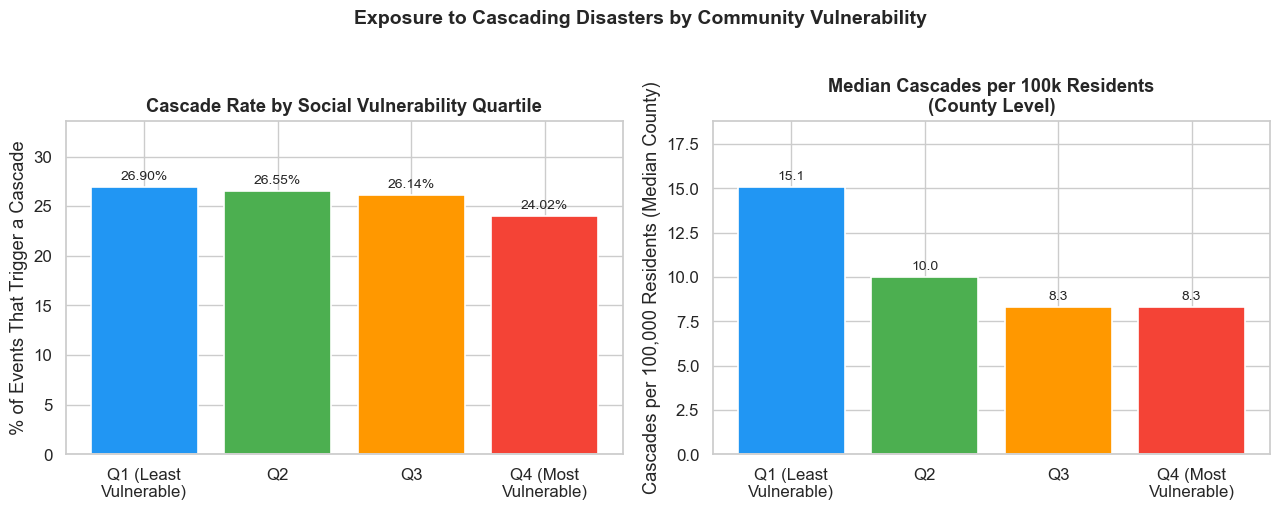

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: cascade rate by quartile
ax = axes[0]
bars = ax.bar(
    QUARTILE_LABELS,
    cascade_by_q['cascade_rate_pct'],
    color=QUARTILE_PALETTE, edgecolor='white', linewidth=1.2
)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax.set_title('Cascade Rate by Social Vulnerability Quartile', fontweight='bold')
ax.set_ylabel('% of Events That Trigger a Cascade')
ax.set_ylim(0, cascade_by_q['cascade_rate_pct'].max() * 1.25)

# ── Panel B: cascade events per 100k residents
# Aggregate to county level first, then normalize by population
county_stats = (
    df.groupby(['COUNTY_FIPS', 'SVI_QUARTILE', 'POPULATION'])
    .agg(total=('is_cascade_result','count'), cascades=('is_cascade_result','sum'))
    .reset_index()
)
county_stats = county_stats[county_stats['POPULATION'] > 0]
county_stats['cascades_per_100k'] = county_stats['cascades'] / county_stats['POPULATION'] * 1e5

ax2 = axes[1]
quartile_rates = (
    county_stats.groupby('SVI_QUARTILE')['cascades_per_100k']
    .median()
    .reset_index()
)
bars2 = ax2.bar(
    QUARTILE_LABELS,
    quartile_rates['cascades_per_100k'],
    color=QUARTILE_PALETTE, edgecolor='white', linewidth=1.2
)
ax2.bar_label(bars2, fmt='%.1f', padding=3, fontsize=10)
ax2.set_title('Median Cascades per 100k Residents\n(County Level)', fontweight='bold')
ax2.set_ylabel('Cascades per 100,000 Residents (Median County)')
ax2.set_ylim(0, quartile_rates['cascades_per_100k'].max() * 1.25)

plt.suptitle('Exposure to Cascading Disasters by Community Vulnerability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_exposure_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()

Chi-square test (cascade rate vs. SVI quartile):
  chi2 = 342.3, dof = 3, p = 6.99e-74



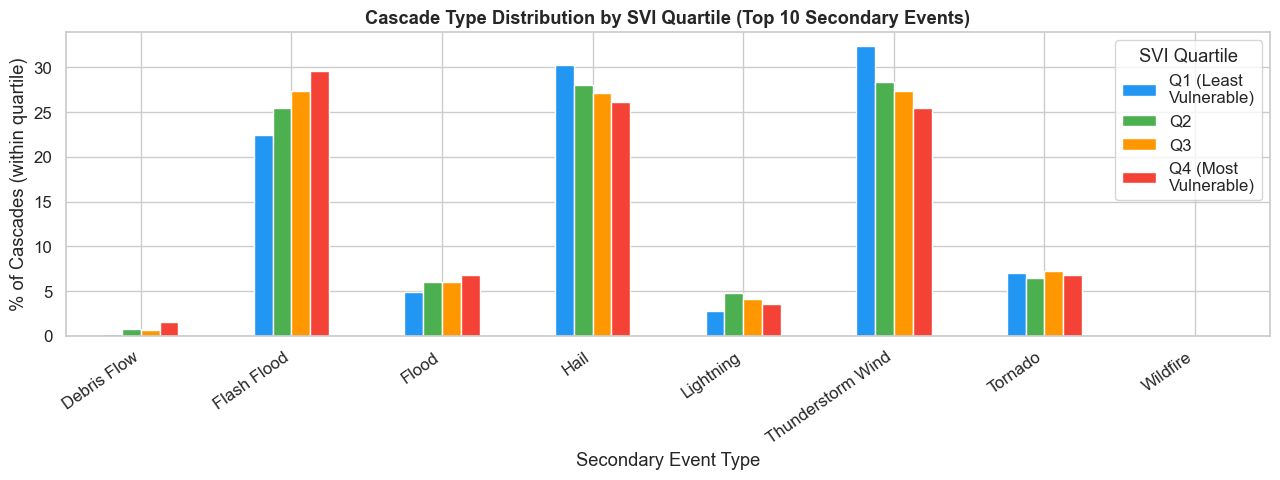

In [97]:
# ── 3.2  Chi-square test: is cascade rate independent of SVI quartile? ─────
contingency = pd.crosstab(df['SVI_QUARTILE'], df['is_cascade_result'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)
print(f'Chi-square test (cascade rate vs. SVI quartile):')
print(f'  chi2 = {chi2:.1f}, dof = {dof}, p = {p_chi2:.2e}')
print()

# ── 3.3  Cascade type breakdown by SVI quartile ────────────────────────────
cascade_df = df[df['is_cascade_result'] == 1].copy()

# Expand multi-type target column (stored as a string list like "['Flash Flood', 'Tornado']")
import ast
def safe_parse(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

cascade_df['target_list'] = cascade_df['target']

# Explode so each row is one (event, secondary_type) pair
cascade_exploded = cascade_df.explode('target_list').rename(columns={'target_list': 'SECONDARY_TYPE'})
cascade_exploded = cascade_exploded.dropna(subset=['SECONDARY_TYPE', 'SVI_QUARTILE'])

# Top 10 secondary types overall
top_types = (
    cascade_exploded['SECONDARY_TYPE']
    .value_counts()
    .head(10)
    .index.tolist()
)

type_q = (
    cascade_exploded[cascade_exploded['SECONDARY_TYPE'].isin(top_types)]
    .groupby(['SVI_QUARTILE', 'SECONDARY_TYPE'])
    .size()
    .unstack(fill_value=0)
)
# Normalize to percentage within each quartile
type_q_pct = type_q.div(type_q.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
type_q_pct.T.plot(kind='bar', ax=ax, color=QUARTILE_PALETTE, edgecolor='white')
ax.set_title('Cascade Type Distribution by SVI Quartile (Top 10 Secondary Events)', fontweight='bold')
ax.set_ylabel('% of Cascades (within quartile)')
ax.set_xlabel('Secondary Event Type')
ax.legend(title='SVI Quartile', labels=QUARTILE_LABELS)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig_cascade_types_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()

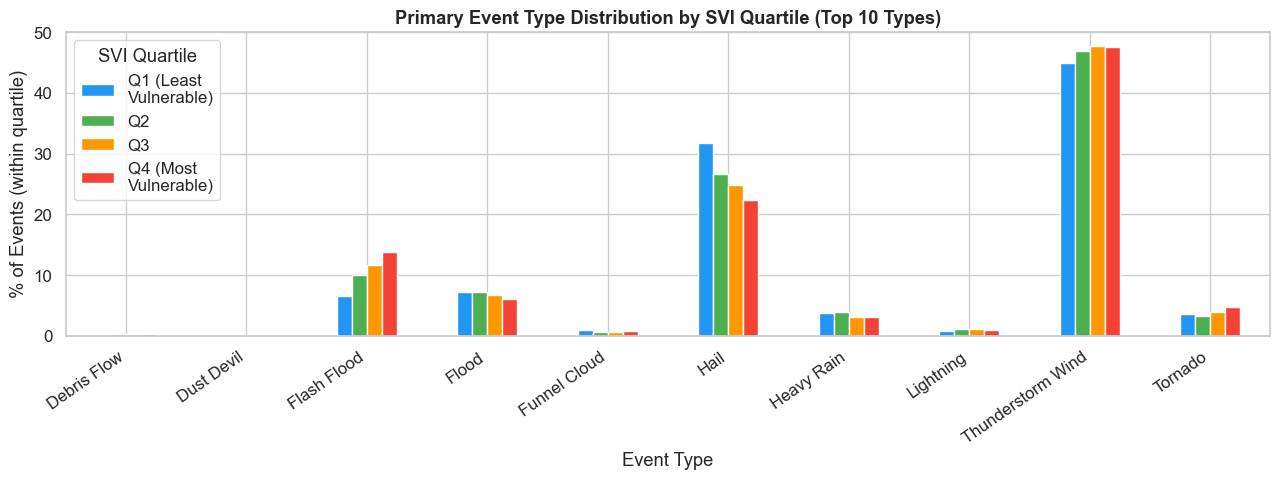

In [98]:
# ── 3.4  Primary event type composition by SVI quartile ───────────────────
top_primary = df['EVENT_TYPE'].value_counts().head(10).index.tolist()

primary_q = (
    df[df['EVENT_TYPE'].isin(top_primary)]
    .groupby(['SVI_QUARTILE', 'EVENT_TYPE'])
    .size()
    .unstack(fill_value=0)
)
primary_q_pct = primary_q.div(primary_q.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
primary_q_pct.T.plot(kind='bar', ax=ax, color=QUARTILE_PALETTE, edgecolor='white')
ax.set_title('Primary Event Type Distribution by SVI Quartile (Top 10 Types)', fontweight='bold')
ax.set_ylabel('% of Events (within quartile)')
ax.set_xlabel('Event Type')
ax.legend(title='SVI Quartile', labels=QUARTILE_LABELS)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig_primary_types_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Impact Analysis

For the same cascade events, do vulnerable communities suffer higher damage, deaths, or injuries?

In [100]:
# 4.1  Damage / deaths / injuries by SVI quartile
# Using log-scale damage to reduce outlier distortion

# 4.1  Damage / deaths / injuries by SVI quartile

# Ensure LOG_DAMAGE exists regardless of cell execution order
cascade_df = cascade_df.copy()
cascade_df['LOG_DAMAGE'] = np.log1p(cascade_df['TOTAL_DAMAGE_USD'])

impact_by_q = (
    cascade_df.groupby('SVI_QUARTILE')
    .agg(
        n_events          = ('is_cascade_result', 'count'),
        median_damage     = ('TOTAL_DAMAGE_USD',  'median'),
        mean_damage       = ('TOTAL_DAMAGE_USD',  'mean'),
        total_damage      = ('TOTAL_DAMAGE_USD',  'sum'),
        median_log_damage = ('LOG_DAMAGE',        'median'),
        mean_log_damage   = ('LOG_DAMAGE',        'mean'),
        median_deaths     = ('TOTAL_DEATHS',      'median'),
        mean_deaths       = ('TOTAL_DEATHS',      'mean'),
        total_deaths      = ('TOTAL_DEATHS',      'sum'),
        total_injuries    = ('TOTAL_INJURIES',     'sum'),
    ).reset_index()
)
print('Impact by SVI Quartile (cascade events only):')
print(impact_by_q[['SVI_QUARTILE','n_events','median_damage','mean_damage',
                    'median_log_damage','mean_deaths']].to_string(index=False))



Impact by SVI Quartile (cascade events only):
 SVI_QUARTILE  n_events  median_damage   mean_damage  median_log_damage  mean_deaths
            1     37549            0.0 116577.587419                0.0     0.001997
            2     39185            0.0 207227.859130                0.0     0.003981
            3     36751            0.0 266432.601562                0.0     0.011102
            4     30621            0.0 475571.999282                0.0     0.005486


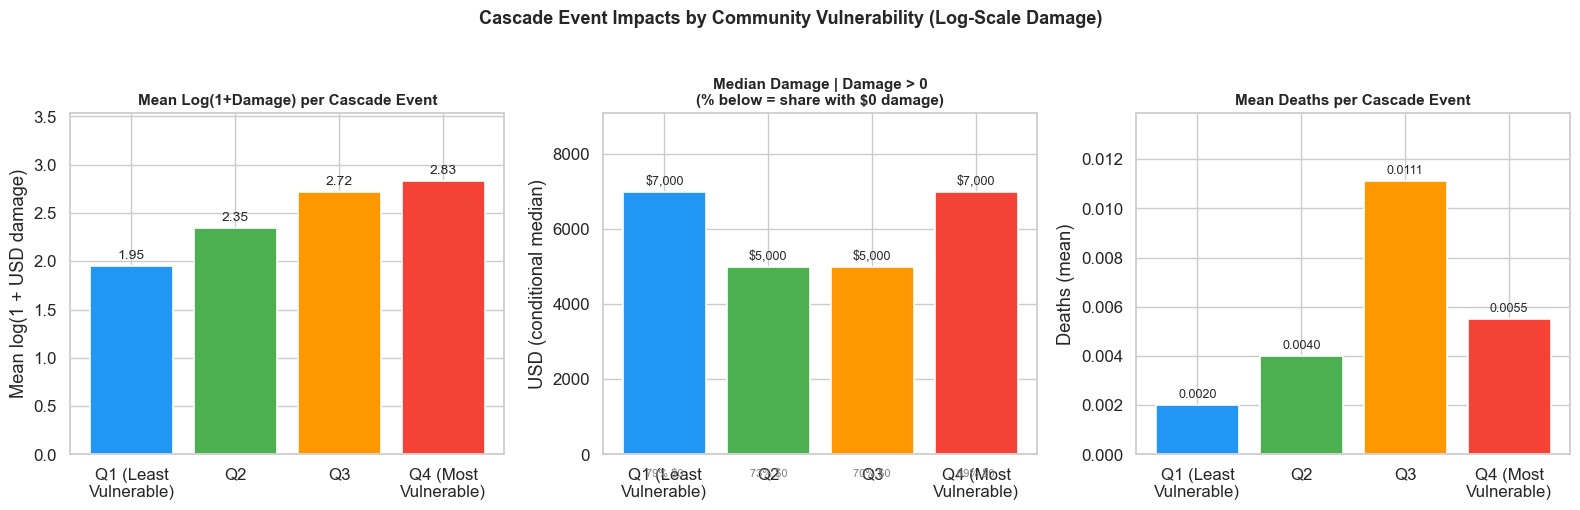

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: mean log-damage (more robust than raw mean)
ax = axes[0]
bars = ax.bar(QUARTILE_LABELS, impact_by_q['mean_log_damage'],
              color=QUARTILE_PALETTE, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='{:.2f}', padding=3, fontsize=10)
ax.set_title('Mean Log(1+Damage) per Cascade Event', fontweight='bold', fontsize=11)
ax.set_ylabel('Mean log(1 + USD damage)')
ax.set_ylim(0, impact_by_q['mean_log_damage'].max() * 1.25)

# Panel B: conditional median damage (given damage > 0)
ax2 = axes[1]
nonzero = cascade_df[cascade_df['TOTAL_DAMAGE_USD'] > 0]
cond_median = (
    nonzero.groupby('SVI_QUARTILE')['TOTAL_DAMAGE_USD']
    .median()
    .reindex([1, 2, 3, 4])
)
zero_rate = (
    cascade_df.groupby('SVI_QUARTILE')['TOTAL_DAMAGE_USD']
    .apply(lambda x: (x == 0).mean())
    .reindex([1, 2, 3, 4])
)
bars2 = ax2.bar(QUARTILE_LABELS, cond_median,
                color=QUARTILE_PALETTE, edgecolor='white', linewidth=1.2)
ax2.bar_label(bars2, labels=[f'${v:,.0f}' for v in cond_median],
              padding=3, fontsize=9)
# Annotate zero-damage rate
for j, (bar, zr) in enumerate(zip(bars2, zero_rate)):
    ax2.text(bar.get_x() + bar.get_width()/2, -ax2.get_ylim()[1]*0.08,
             f'{zr:.0%} $0', ha='center', fontsize=8, color='gray')
ax2.set_title('Median Damage | Damage > 0\n(% below = share with $0 damage)',
              fontweight='bold', fontsize=11)
ax2.set_ylabel('USD (conditional median)')
ax2.set_ylim(0, cond_median.max() * 1.3)


# Panel C: mean deaths
ax3 = axes[2]
bars3 = ax3.bar(QUARTILE_LABELS, impact_by_q['mean_deaths'],
                color=QUARTILE_PALETTE, edgecolor='white', linewidth=1.2)
ax3.bar_label(bars3, fmt='{:.4f}', padding=3, fontsize=9)
ax3.set_title('Mean Deaths per Cascade Event', fontweight='bold', fontsize=11)
ax3.set_ylabel('Deaths (mean)')
ax3.set_ylim(0, impact_by_q['mean_deaths'].max() * 1.25)

plt.suptitle('Cascade Event Impacts by Community Vulnerability (Log-Scale Damage)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_impact_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()


In [102]:
# 4.2  Kruskal-Wallis tests
groups_log  = [cascade_df[cascade_df['SVI_QUARTILE']==q]['LOG_DAMAGE'].dropna().values     for q in [1,2,3,4]]
groups_raw  = [cascade_df[cascade_df['SVI_QUARTILE']==q]['TOTAL_DAMAGE_USD'].dropna().values for q in [1,2,3,4]]
groups_dead = [cascade_df[cascade_df['SVI_QUARTILE']==q]['TOTAL_DEATHS'].dropna().values    for q in [1,2,3,4]]

kw_log,  p_log  = stats.kruskal(*groups_log)
kw_raw,  p_raw  = stats.kruskal(*groups_raw)
kw_dead, p_dead = stats.kruskal(*groups_dead)

print('Kruskal-Wallis tests (non-parametric ANOVA across SVI quartiles):')
print(f'  Log(1+damage): H = {kw_log:.2f},  p = {p_log:.2e}')
print(f'  Raw damage   : H = {kw_raw:.2f},  p = {p_raw:.2e}')
print(f'  Deaths       : H = {kw_dead:.2f}, p = {p_dead:.2e}')


Kruskal-Wallis tests (non-parametric ANOVA across SVI quartiles):
  Log(1+damage): H = 1062.84,  p = 4.21e-230
  Raw damage   : H = 1062.84,  p = 4.21e-230
  Deaths       : H = 39.90, p = 1.12e-08


In [106]:
# 4.3  Within-event-type comparison: Q4 vs Q1 damage (mean, median, log-mean)
MIN_EVENTS = 50

type_q = (
    cascade_df[cascade_df['SVI_QUARTILE'].isin([1, 4])]
    .groupby(['EVENT_TYPE', 'SVI_QUARTILE'])
    .agg(n=('is_cascade_result','count'),
         mean_damage=('TOTAL_DAMAGE_USD','mean'),
         median_damage=('TOTAL_DAMAGE_USD','median'),
         mean_log=('LOG_DAMAGE','mean'))
    .unstack('SVI_QUARTILE')
)
type_q.columns = ['n_q1','n_q4','mean_dmg_q1','mean_dmg_q4','med_dmg_q1','med_dmg_q4','mlog_q1','mlog_q4']
type_q = type_q[(type_q['n_q1'] >= MIN_EVENTS) & (type_q['n_q4'] >= MIN_EVENTS)].copy()

type_q['mean_ratio_q4_q1']   = type_q['mean_dmg_q4'] / type_q['mean_dmg_q1'].replace(0, np.nan)
type_q['median_ratio_q4_q1'] = type_q['med_dmg_q4']  / type_q['med_dmg_q1'].replace(0, np.nan)
type_q['log_diff_q4_q1']     = type_q['mlog_q4'] - type_q['mlog_q1']  # additive on log scale
type_q = type_q.sort_values('log_diff_q4_q1', ascending=False)

print('Within-event-type damage comparison Q4 vs Q1 (>0 = more damage in vulnerable counties):')
print('  log_diff_q4_q1 = mean log-damage difference (more robust than raw ratio)')
print(type_q[['n_q1','n_q4','mean_ratio_q4_q1','median_ratio_q4_q1','log_diff_q4_q1']].head(15).round(3).to_string())


Within-event-type damage comparison Q4 vs Q1 (>0 = more damage in vulnerable counties):
  log_diff_q4_q1 = mean log-damage difference (more robust than raw ratio)
                    n_q1   n_q4  mean_ratio_q4_q1  median_ratio_q4_q1  log_diff_q4_q1
EVENT_TYPE                                                                           
Tornado             1670   1521             1.957                 NaN           2.491
Thunderstorm Wind  16990  14447             1.066                 NaN           0.920
Lightning            135    247             1.006                 2.0           0.670
Heavy Rain           946    918            38.650                 NaN           0.653
Flash Flood         1533   2005             6.761                 NaN           0.467
Hail               15554  10665             2.720                 NaN           0.268
Funnel Cloud         681    357               NaN                 NaN           0.000


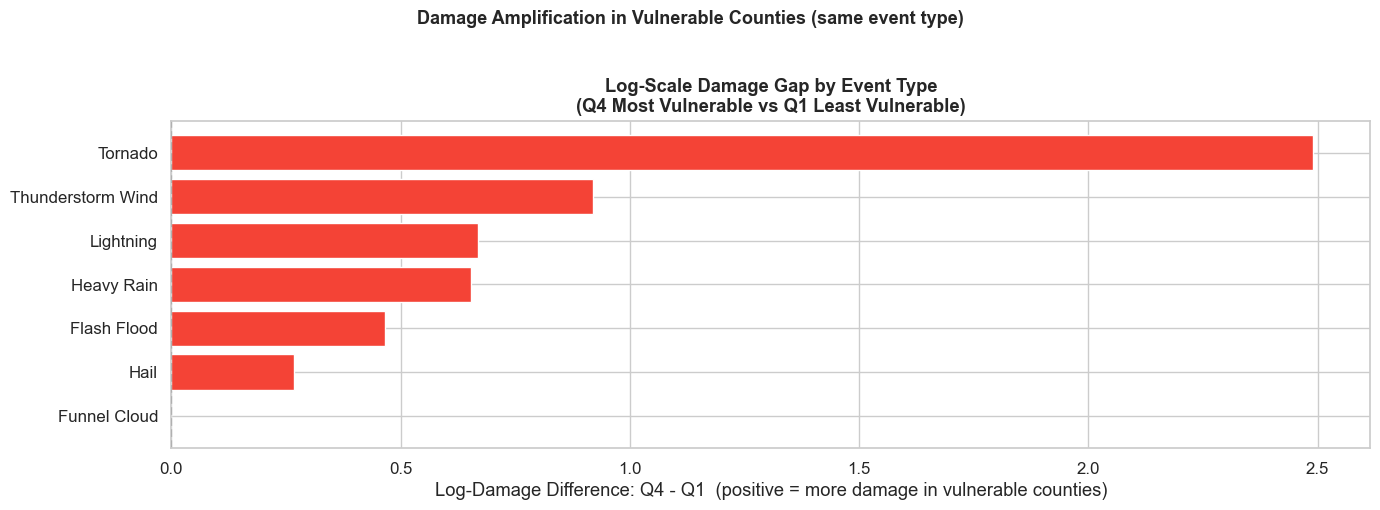

In [110]:
# Visualize log-damage difference Q4 vs Q1
plot_df = type_q[type_q['log_diff_q4_q1'].notna()].head(15)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Panel A: log-damage difference
bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in plot_df['log_diff_q4_q1']]
ax.barh(plot_df.index[::-1], plot_df['log_diff_q4_q1'][::-1], color=bar_colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Log-Damage Difference: Q4 - Q1  (positive = more damage in vulnerable counties)')
ax.set_title('Log-Scale Damage Gap by Event Type\n(Q4 Most Vulnerable vs Q1 Least Vulnerable)', fontweight='bold')

plt.suptitle('Damage Amplification in Vulnerable Counties (same event type)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_damage_ratio_by_type.png', dpi=150, bbox_inches='tight')
plt.show()


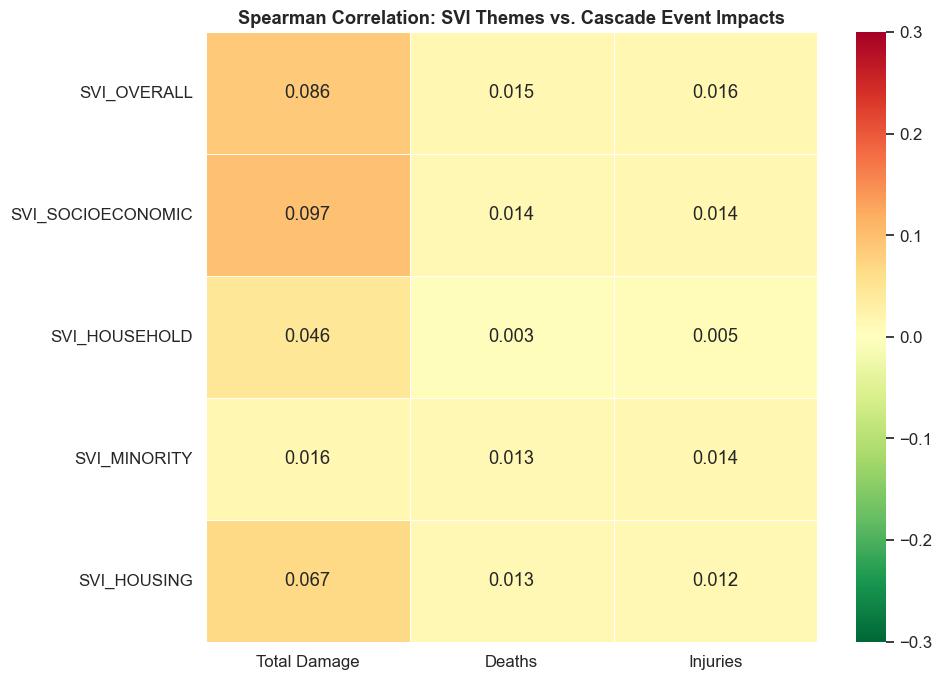

In [108]:
# ── 4.4  Correlations: SVI themes vs. damage ──────────────────────────────
svi_themes = ['SVI_OVERALL', 'SVI_SOCIOECONOMIC', 'SVI_HOUSEHOLD', 'SVI_MINORITY', 'SVI_HOUSING']
svi_themes = [c for c in svi_themes if c in cascade_df.columns]

if svi_themes:
    corr_data = cascade_df[svi_themes + ['TOTAL_DAMAGE_USD', 'TOTAL_DEATHS', 'TOTAL_INJURIES']].dropna()
    corr_matrix = corr_data.corr(method='spearman')

    fig, ax = plt.subplots(figsize=(10, 7))
    mask = np.zeros_like(corr_matrix, dtype=bool)
    # Show only the cross-correlations between SVI themes and impact metrics
    subset = corr_matrix.loc[svi_themes, ['TOTAL_DAMAGE_USD', 'TOTAL_DEATHS', 'TOTAL_INJURIES']]
    sns.heatmap(subset, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0,
                vmin=-0.3, vmax=0.3, ax=ax, linewidths=0.5)
    ax.set_title('Spearman Correlation: SVI Themes vs. Cascade Event Impacts', fontweight='bold')
    ax.set_xticklabels(['Total Damage', 'Deaths', 'Injuries'], rotation=0)
    plt.tight_layout()
    plt.savefig('fig_svi_impact_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4b. Regression Analysis

Controlling for event type, year, and state to isolate the association between social vulnerability and cascade risk / damage.

In [111]:
# 4b-i  Logistic regression: is_cascade_result ~ SVI_OVERALL + event type + state
# Controls for hazard mix and geography to isolate the SVI association
try:
    import statsmodels.formula.api as smf

    reg_df = df.dropna(subset=['SVI_OVERALL','EVENT_TYPE','YEAR','is_cascade_result']).copy()
    # Clean column names for patsy formula (remove special characters)
    reg_df['etype']  = reg_df['EVENT_TYPE'].str.replace('[^a-zA-Z0-9]','_', regex=True)
    reg_df['yr_cat'] = reg_df['YEAR'].astype(int).astype(str)
    if 'STATE_ABBR' in reg_df.columns:
        reg_df['state'] = reg_df['STATE_ABBR'].fillna('UNK')
    else:
        reg_df['state'] = 'UNK'

    # Sample for speed (stratified on outcome)
    n_samp = min(80_000, len(reg_df))
    reg_sample = reg_df.sample(n=n_samp, random_state=42)

    logit = smf.logit(
        'is_cascade_result ~ SVI_OVERALL + C(etype) + C(yr_cat) + C(state)',
        data=reg_sample
    ).fit(method='bfgs', maxiter=300, disp=False)

    svi_coef = logit.params['SVI_OVERALL']
    svi_pval = logit.pvalues['SVI_OVERALL']
    svi_or   = float(np.exp(svi_coef))
    ci_lo, ci_hi = float(np.exp(logit.conf_int().loc['SVI_OVERALL', 0])),                    float(np.exp(logit.conf_int().loc['SVI_OVERALL', 1]))

    print('Logistic Regression: P(cascade) ~ SVI + event_type + year + state')
    print(f'  n = {n_samp:,} (sampled)  |  pseudo-R2 = {logit.prsquared:.4f}')
    print()
    print(f'  SVI_OVERALL coefficient : {svi_coef:+.4f}')
    print(f'  Odds Ratio              : {svi_or:.4f}  (95% CI: {ci_lo:.4f} - {ci_hi:.4f})')
    print(f'  p-value                 : {svi_pval:.3e}')
    print()
    if svi_or < 1:
        print('  Interpretation: higher social vulnerability is associated with LOWER')
        print('  cascade probability after controlling for event type, year, and state.')
        print('  This suggests vulnerable counties face different hazard mixes, not')
        print('  intrinsically higher per-event cascade rates.')
    else:
        print('  Interpretation: higher social vulnerability is associated with HIGHER')
        print('  cascade probability after controlling for event type, year, and state.')

except ImportError:
    print('statsmodels not installed. Run: pip install statsmodels')
except Exception as e:
    print(f'Regression failed: {e}')


Logistic Regression: P(cascade) ~ SVI + event_type + year + state
  n = 80,000 (sampled)  |  pseudo-R2 = 0.0724

  SVI_OVERALL coefficient : +0.0919
  Odds Ratio              : 1.0962  (95% CI: 1.0159 - 1.1829)
  p-value                 : 1.796e-02

  Interpretation: higher social vulnerability is associated with HIGHER
  cascade probability after controlling for event type, year, and state.


/opt/homebrew/Caskroom/miniconda/base/envs/10718/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [112]:
# 4b-ii  OLS regression: log-damage ~ SVI_OVERALL + event type + year
# Among cascade events, does SVI predict damage after controlling for hazard type?
try:
    import statsmodels.formula.api as smf

    ols_df = cascade_df.dropna(subset=['LOG_DAMAGE','SVI_OVERALL','EVENT_TYPE','YEAR']).copy()
    ols_df['etype']  = ols_df['EVENT_TYPE'].str.replace('[^a-zA-Z0-9]','_', regex=True)
    ols_df['yr_cat'] = ols_df['YEAR'].astype(int).astype(str)
    if 'STATE_ABBR' in ols_df.columns:
        ols_df['state'] = ols_df['STATE_ABBR'].fillna('UNK')
    else:
        ols_df['state'] = 'UNK'

    # Zero-damage events dominate; restrict to events with any reported damage
    ols_nonzero = ols_df[ols_df['TOTAL_DAMAGE_USD'] > 0]
    print(f'Cascade events with damage > 0: {len(ols_nonzero):,} / {len(ols_df):,}')

    ols = smf.ols(
        'LOG_DAMAGE ~ SVI_OVERALL + C(etype) + C(yr_cat) + C(state)',
        data=ols_nonzero
    ).fit()

    svi_coef = ols.params['SVI_OVERALL']
    svi_pval = ols.pvalues['SVI_OVERALL']
    ci_lo, ci_hi = ols.conf_int().loc['SVI_OVERALL']

    print()
    print('OLS Regression: log(1+damage) ~ SVI + event_type + year + state')
    print(f'  n = {len(ols_nonzero):,}  |  R2 = {ols.rsquared:.4f}  |  Adj-R2 = {ols.rsquared_adj:.4f}')
    print()
    print(f'  SVI_OVERALL coefficient : {svi_coef:+.4f}')
    print(f'  95% CI                  : [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    print(f'  p-value                 : {svi_pval:.3e}')
    print()
    if abs(svi_coef) < 0.05 or svi_pval > 0.05:
        print('  Interpretation: no statistically significant association between SVI and')
        print('  log-damage after controlling for event type, year, and state.')
    elif svi_coef > 0:
        print('  Interpretation: higher vulnerability is associated with higher damage')
        print('  after controlling for event type, year, and state.')
    else:
        print('  Interpretation: higher vulnerability is associated with lower damage')
        print('  after controlling for event type, year, and state.')

except ImportError:
    print('statsmodels not installed. Run: pip install statsmodels')
except Exception as e:
    print(f'Regression failed: {e}')


Cascade events with damage > 0: 39,163 / 144,106

OLS Regression: log(1+damage) ~ SVI + event_type + year + state
  n = 39,163  |  R2 = 0.2561  |  Adj-R2 = 0.2547

  SVI_OVERALL coefficient : +0.0465
  95% CI                  : [-0.0379, +0.1308]
  p-value                 : 2.802e-01

  Interpretation: no statistically significant association between SVI and
  log-damage after controlling for event type, year, and state.


## 5. Prediction Fairness Analysis

Does our XGBoost multilabel cascade model perform equally well across SVI vulnerability quartiles?

**Data**: `X_test` (2023–2025) with 16 per-label models and tuned thresholds.
**SVI**: 2022 vintage (most recent; matches test period).

Key metrics:
- **FNR gap (Q4 − Q1)**: positive = model misses more cascades in most-vulnerable counties
- **Brier score by quartile**: calibration quality per group


In [113]:
import xgboost as xgb

# X_test / y_test already loaded in Section 1 — reuse those arrays.
# y_binary: 1 if ANY of the 16 cascade types is triggered
y_binary = (y_test.sum(axis=1) > 0).astype(int)

print(f'Test set: {X_test.shape[0]:,} samples')
print(f'Binary cascade rate in test: {y_binary.mean():.4f}')
print(f'\nLoading multilabel models from: {MULTILABEL_MODEL_DIR}')

# Load all per-label pkl models
models_ml = {}
for pkl_path in sorted(MULTILABEL_MODEL_DIR.glob('*.pkl')):
    label = pkl_path.stem  # e.g. "Flash Flood"
    if label == '_checkpoint':
        continue
    with open(pkl_path, 'rb') as f:
        models_ml[label] = pickle.load(f)

print(f'Loaded {len(models_ml)} models: {list(models_ml.keys())}')

Test set: 193,489 samples
Binary cascade rate in test: 0.1926

Loading multilabel models from: /Users/varshel/Documents/10718/Project/cascading-disaster-prediction/models/baseline/xgb_models_no_cascade_prob
Loaded 16 models: ['Blizzard', 'Cold_Wind Chill', 'Debris Flow', 'Excessive Heat', 'Extreme Cold_Wind Chill', 'Flash Flood', 'Flood', 'Hail', 'Heat', 'Heavy Snow', 'Lightning', 'Marine Thunderstorm Wind', 'Thunderstorm Wind', 'Tornado', 'Waterspout', 'Wildfire']


In [114]:
# ── Multilabel predictions ─────────────────────────────────────────────────
print('Running predictions across all labels (may take ~60 s)...')

# Drop cascade probability features — models trained without them
cascade_prob_idx = [i for i, f in enumerate(feature_names)
                    if (f.startswith('p_') and f.endswith('_given_primary'))
                    or f == 'total_cascade_probability']
keep_idx = [i for i in range(X_test.shape[1]) if i not in cascade_prob_idx]
X_test_filtered = X_test[:, keep_idx]

n_test   = X_test_filtered.shape[0]
n_labels = len(target_names)

# Probability matrix: (n_test x n_labels)
y_prob_ml = np.zeros((n_test, n_labels))

for i, label in enumerate(target_names):
    sanitized = label.replace('/', '_')
    if sanitized in models_ml:
        y_prob_ml[:, i] = models_ml[sanitized].predict_proba(X_test_filtered)[:, 1]
    else:
        print(f'  Warning: no model found for "{label}" (sanitized: "{sanitized}")')

THRESHOLDS = {
    'Blizzard':                 0.0681,
    'Cold/Wind Chill':          0.0250,
    'Debris Flow':              0.1690,
    'Excessive Heat':           0.2733,
    'Extreme Cold/Wind Chill':  0.1891,
    'Flash Flood':              0.2274,
    'Flood':                    0.2797,
    'Hail':                     0.3912,
    'Heat':                     0.3331,
    'Heavy Snow':               0.0582,
    'Lightning':                0.0612,
    'Marine Thunderstorm Wind': 0.4364,
    'Thunderstorm Wind':        0.6249,
    'Tornado':                  0.1251,
    'Waterspout':               0.1361,
    'Wildfire':                 0.0286,
}

# Apply per-label tuned thresholds
y_pred_ml = np.zeros_like(y_prob_ml, dtype=int)
for i, label in enumerate(target_names):
    thresh = THRESHOLDS.get(label, 0.5)
    y_pred_ml[:, i] = (y_prob_ml[:, i] >= thresh).astype(int)

# ── Overall multilabel metrics ─────────────────────────────────────────────
from sklearn.metrics import hamming_loss, jaccard_score

print(f'\nOverall Multilabel Test Results:')
print(f'  Hamming loss:    {hamming_loss(y_test, y_pred_ml):.4f}')
print(f'  Macro F1:        {f1_score(y_test, y_pred_ml, average="macro",    zero_division=0):.4f}')
print(f'  Micro F1:        {f1_score(y_test, y_pred_ml, average="micro",    zero_division=0):.4f}')
print(f'  Jaccard (macro): {jaccard_score(y_test, y_pred_ml, average="macro", zero_division=0):.4f}')
print()
print(f'{"Label":<35} {"Support":>8} {"F1":>6} {"Prec":>6} {"Recall":>7}')
print('-' * 65)
for i, label in enumerate(target_names):
    sup = y_test[:, i].sum()
    f1  = f1_score(y_test[:, i], y_pred_ml[:, i], zero_division=0)
    pr  = precision_score(y_test[:, i], y_pred_ml[:, i], zero_division=0)
    rc  = recall_score(y_test[:, i], y_pred_ml[:, i], zero_division=0)
    print(f'  {label:<33} {sup:>8,.0f} {f1:>6.3f} {pr:>6.3f} {rc:>7.3f}')


Running predictions across all labels (may take ~60 s)...

Overall Multilabel Test Results:
  Hamming loss:    0.1577
  Macro F1:        0.1839
  Micro F1:        0.1427
  Jaccard (macro): 0.1145

Label                                Support     F1   Prec  Recall
-----------------------------------------------------------------
  Blizzard                               164  0.010  0.005   0.848
  Cold/Wind Chill                        206  0.002  0.001   1.000
  Debris Flow                            292  0.055  0.029   0.791
  Excessive Heat                       3,070  0.434  0.281   0.950
  Extreme Cold/Wind Chill                169  0.104  0.056   0.627
  Flash Flood                          9,973  0.257  0.148   0.957
  Flood                                1,869  0.260  0.152   0.890
  Hail                                 9,749  0.395  0.248   0.971
  Heat                                 2,406  0.411  0.261   0.963
  Heavy Snow                             152  0.041  0.021   0.697


In [115]:
# ── Build test county FIPS from feature matrix ────────────────────────────
STATE_IDX = feature_names.index('STATE_FIPS')
CZ_IDX    = feature_names.index('CZ_FIPS')

test_county_fips = pd.array(
    X_test[:, STATE_IDX].astype(float) * 1000 + X_test[:, CZ_IDX].astype(float),
    dtype='Int64'
)

# ── Load SVI 2022 for test-set fairness (most recent vintage; test = 2023–2025) ─
svi_2022 = pd.read_csv(SVI_RAW_DIR / 'SVI_2022_US_county.csv', dtype={'FIPS': str})
svi_2022['COUNTY_FIPS'] = pd.to_numeric(svi_2022['FIPS'], errors='coerce').astype('Int64')
svi_2022 = svi_2022.replace(-999, np.nan)
svi_2022['SVI_QUARTILE'] = pd.qcut(svi_2022['RPL_THEMES'], 4, labels=[1,2,3,4]).astype('Int64')

print(f'SVI 2022 counties: {len(svi_2022):,}')
match_n = test_county_fips.isin(svi_2022['COUNTY_FIPS']).sum()
print(f'Test rows matching SVI 2022: {match_n:,} / {len(test_county_fips):,} '
      f'({100*match_n/len(test_county_fips):.1f}%)')


SVI 2022 counties: 3,144
Test rows matching SVI 2022: 144,466 / 193,489 (74.7%)


SVI 2022 match rate: 74.66%  (144,466 / 193,489)

Missingness audit -- do unmatched rows differ materially?
 matched      n  cascade_rate  pred_positive_rate  mean_score
 Matched 144466      0.229113                 1.0    0.575079
No match  49023      0.084940                 1.0    0.464243

Labels with >=30 test positives (used for fairness): 16/16

Per-label FNR by SVI Quartile (support-filtered labels):
                          Q1_FNR  Q2_FNR  Q3_FNR  Q4_FNR  FNR_gap_Q4_Q1
label                                                                  
Lightning                  0.216   0.300   0.123   0.463          0.248
Blizzard                   0.000   0.182   0.200   0.125          0.125
Flash Flood                0.041   0.025   0.029   0.062          0.021
Flood                      0.105   0.088   0.095   0.125          0.020
Tornado                    0.013   0.011   0.011   0.026          0.013
Hail                       0.025   0.028   0.027   0.035          0.010
Heavy Snow  

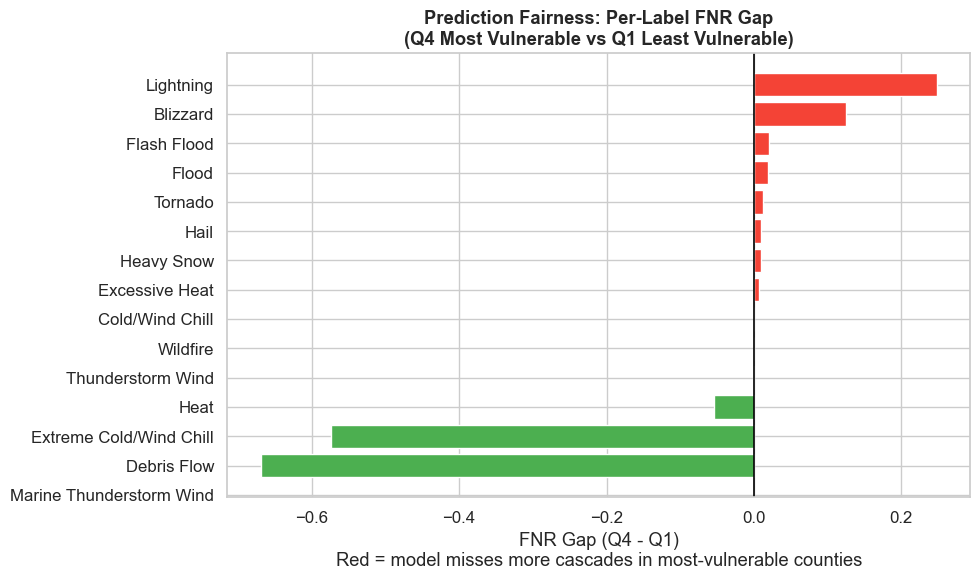

In [116]:
# 5.1  Per-label FNR by SVI quartile  (test set only, SVI 2022)

STATE_IDX = feature_names.index('STATE_FIPS')
CZ_IDX    = feature_names.index('CZ_FIPS')
test_fips = pd.array(
    X_test[:, STATE_IDX].astype(float) * 1000 + X_test[:, CZ_IDX].astype(float),
    dtype='Int64'
)

# Build full test DataFrame (all rows, no dropna yet)
test_df = pd.DataFrame({
    'COUNTY_FIPS': test_fips,
    'y_true_any':  (y_test.sum(axis=1) > 0).astype(int),
    'y_pred_any':  (y_pred_ml.sum(axis=1) > 0).astype(int),
    'y_prob_max':  y_prob_ml.max(axis=1),
})
for i, label in enumerate(target_names):
    test_df[f'true_{label}'] = y_test[:, i]
    test_df[f'pred_{label}'] = y_pred_ml[:, i]
    test_df[f'prob_{label}'] = y_prob_ml[:, i]

# Left-join SVI 2022 to keep ALL rows for missingness audit
test_df = test_df.merge(
    svi_2022[['COUNTY_FIPS', 'SVI_QUARTILE']],
    on='COUNTY_FIPS', how='left'
)

# ── Missingness audit ──────────────────────────────────────────────────────
matched = test_df['SVI_QUARTILE'].notna()
print(f'SVI 2022 match rate: {matched.mean():.2%}  ({matched.sum():,} / {len(test_df):,})')
miss_audit = (
    test_df.assign(matched=matched.map({True: 'Matched', False: 'No match'}))
    .groupby('matched')
    .agg(n=('y_true_any','count'),
         cascade_rate=('y_true_any','mean'),
         pred_positive_rate=('y_pred_any','mean'),
         mean_score=('y_prob_max','mean'))
    .reset_index()
)
print()
print('Missingness audit -- do unmatched rows differ materially?')
print(miss_audit.to_string(index=False))

# ── Drop unmatched; support filter ────────────────────────────────────────
test_df = test_df.dropna(subset=['SVI_QUARTILE']).copy()
test_df['SVI_QUARTILE'] = test_df['SVI_QUARTILE'].astype(int)

# Require >= 30 positives in the full test set for a label to be included
label_support = pd.Series({lb: y_test[:, i].sum() for i, lb in enumerate(target_names)})
valid_labels  = label_support[label_support >= 30].index.tolist()
print(f'\nLabels with >=30 test positives (used for fairness): {len(valid_labels)}/{len(target_names)}')
dropped_labels = [l for l in target_names if l not in valid_labels]
if dropped_labels:
    print(f'  Excluded (low support): {dropped_labels}')

# ── Per-label FNR by quartile ─────────────────────────────────────────────
records = []
for q in [1, 2, 3, 4]:
    sub = test_df[test_df['SVI_QUARTILE'] == q]
    for label in valid_labels:
        yt = sub[f'true_{label}'].values
        yp = sub[f'pred_{label}'].values
        tp = int(((yt == 1) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        records.append({
            'SVI_QUARTILE': q,
            'label':        label,
            'support':      int(yt.sum()),
            'f1':           f1_score(yt, yp, zero_division=0),
            'fnr':          fn / (tp + fn) if (tp + fn) > 0 else np.nan,
            'recall':       recall_score(yt, yp, zero_division=0),
        })

fairness_ml = pd.DataFrame(records)

fnr_pivot = fairness_ml.pivot(index='label', columns='SVI_QUARTILE', values='fnr')
fnr_pivot.columns = [f'Q{q}_FNR' for q in fnr_pivot.columns]
fnr_pivot['FNR_gap_Q4_Q1'] = fnr_pivot['Q4_FNR'] - fnr_pivot['Q1_FNR']
fnr_pivot = fnr_pivot.sort_values('FNR_gap_Q4_Q1', ascending=False)

print('\nPer-label FNR by SVI Quartile (support-filtered labels):')
print(fnr_pivot.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F44336' if g > 0 else '#4CAF50' for g in fnr_pivot['FNR_gap_Q4_Q1']]
ax.barh(fnr_pivot.index[::-1], fnr_pivot['FNR_gap_Q4_Q1'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('FNR Gap (Q4 - Q1)\nRed = model misses more cascades in most-vulnerable counties')
ax.set_title('Prediction Fairness: Per-Label FNR Gap\n(Q4 Most Vulnerable vs Q1 Least Vulnerable)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fnr_gap_per_label.png', dpi=150, bbox_inches='tight')
plt.show()


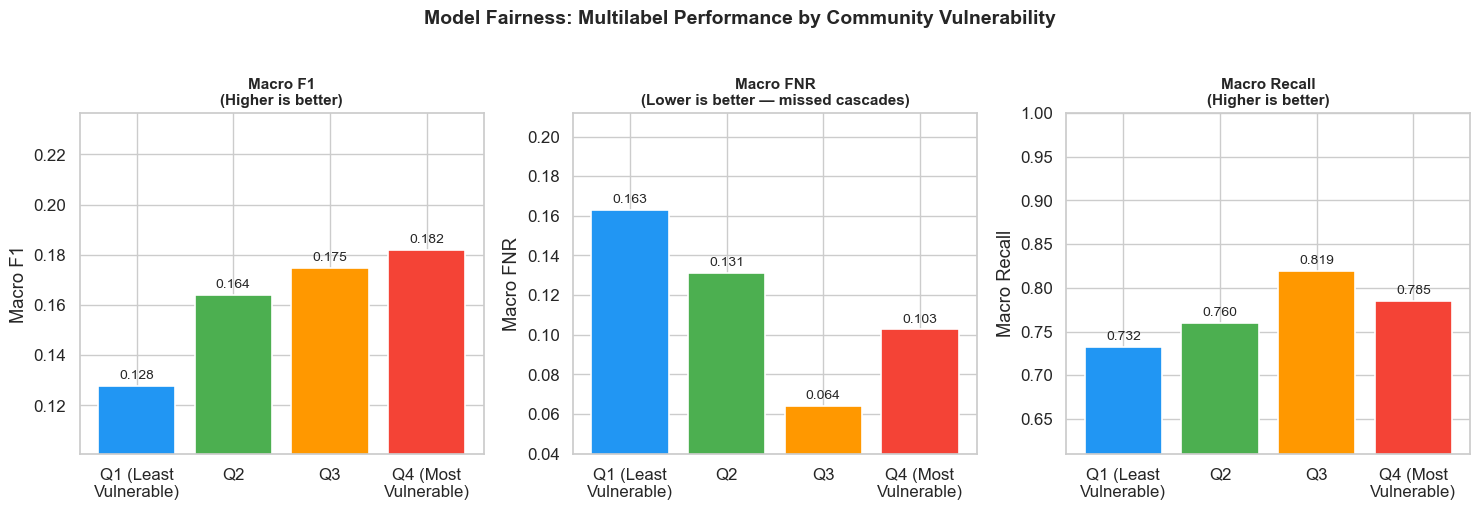

 SVI_QUARTILE  f1_macro  fnr_macro  recall_macro
            1  0.127801   0.162995      0.732380
            2  0.164109   0.131125      0.760266
            3  0.174844   0.064103      0.818910
            4  0.181906   0.102635      0.785194


In [117]:
# ── 5.2  Fairness visualization ────────────────────────────────────────────
# Aggregate per-label metrics to quartile level (macro-average across labels)
fairness_agg = (
    fairness_ml.groupby('SVI_QUARTILE')
    .agg(
        f1_macro=('f1',  'mean'),
        fnr_macro=('fnr', 'mean'),
        recall_macro=('recall', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fairness_metrics = [
    ('f1_macro',     'Macro F1',                   'Higher is better'),
    ('fnr_macro',    'Macro FNR',                  'Lower is better — missed cascades'),
    ('recall_macro', 'Macro Recall',               'Higher is better'),
]

for ax, (metric, label, note) in zip(axes, fairness_metrics):
    vals = fairness_agg[metric].values
    bars = ax.bar(QUARTILE_LABELS, vals, color=QUARTILE_PALETTE, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=10)
    ax.set_title(f'{label}\n({note})', fontweight='bold', fontsize=11)
    ax.set_ylabel(label)
    pad = max(vals) * 0.15
    ax.set_ylim(max(0, min(vals) - pad), min(1, max(vals) + pad * 2))

plt.suptitle('Model Fairness: Multilabel Performance by Community Vulnerability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_fairness_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()

print(fairness_agg.to_string(index=False))


In [118]:
# ── 5.3  Equalized odds gap ───────────────────────────────────────────────
# Equalized odds requires equal TPR and FPR across groups.
# We report the gap between Q4 (most vulnerable) and Q1 (least vulnerable).

q1 = fairness_agg[fairness_agg['SVI_QUARTILE'] == 1].iloc[0]
q4 = fairness_agg[fairness_agg['SVI_QUARTILE'] == 4].iloc[0]

print('Equalized Odds Gap (Q4 − Q1) — macro-averaged across cascade types:')
print(f'  Recall gap: {q4["recall_macro"] - q1["recall_macro"]:+.4f}')
print(f'  FNR gap:    {q4["fnr_macro"]    - q1["fnr_macro"]:+.4f}')
print()

# Disparate impact from the descriptive analysis (cascade rate in df)
di_q1 = cascade_by_q[cascade_by_q['SVI_QUARTILE'] == 1]['cascade_rate'].values[0]
di_q4 = cascade_by_q[cascade_by_q['SVI_QUARTILE'] == 4]['cascade_rate'].values[0]
di = di_q4 / di_q1
print('Disparate Impact (Q4 cascade rate / Q1 cascade rate):')
print(f'  {di:.3f}  (>1 = more cascades in Q4; parity range: 0.8–1.2)')
print()

fnr_gap = q4['fnr_macro'] - q1['fnr_macro']
print('Interpretation:')
if fnr_gap > 0.02:
    print('  ⚠ The model misses more cascades in the MOST vulnerable communities (higher FNR in Q4).')
    print('    This means the model under-warns communities least equipped to handle surprise cascades.')
elif fnr_gap < -0.02:
    print('  ⚠ The model misses more cascades in the LEAST vulnerable communities (higher FNR in Q1).')
else:
    print('  ✓ FNR is approximately equal across quartiles.')


Equalized Odds Gap (Q4 − Q1) — macro-averaged across cascade types:
  Recall gap: +0.0528
  FNR gap:    -0.0604

Disparate Impact (Q4 cascade rate / Q1 cascade rate):
  0.893  (>1 = more cascades in Q4; parity range: 0.8–1.2)

Interpretation:
  ⚠ The model misses more cascades in the LEAST vulnerable communities (higher FNR in Q1).


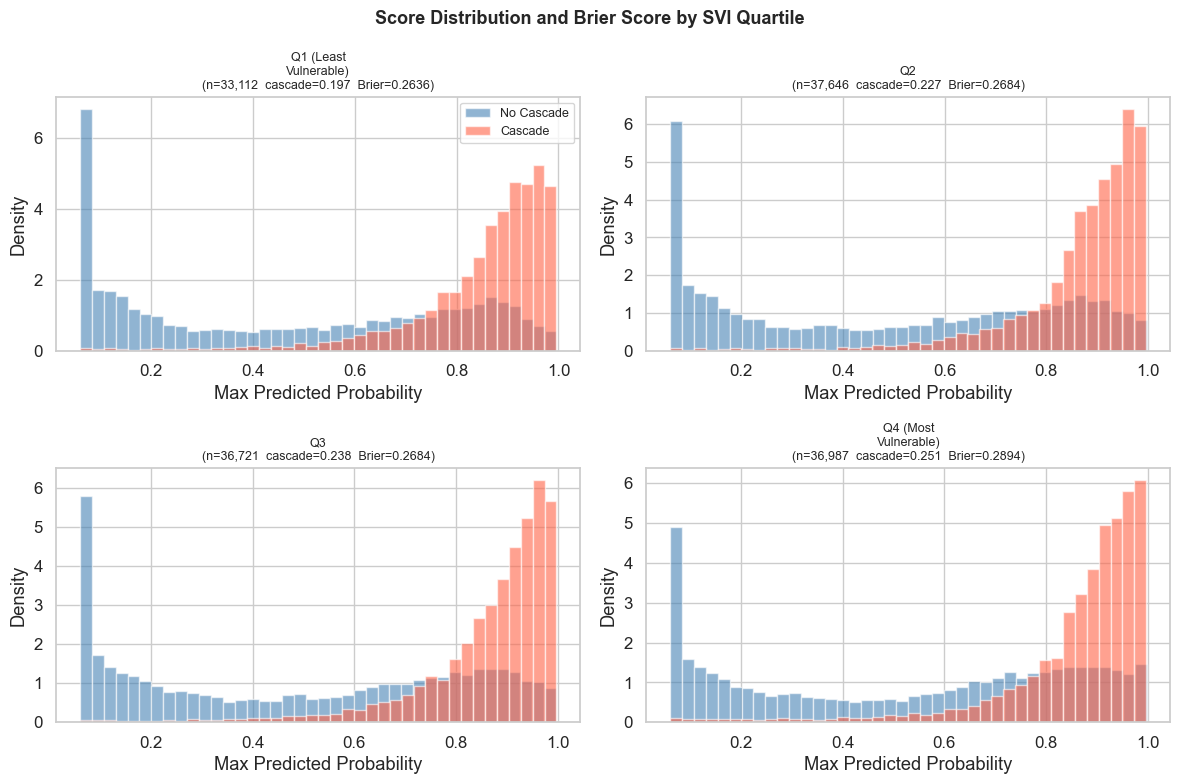

Brier score by SVI quartile (lower = better calibration):
 SVI_QUARTILE     n  cascade_rate  brier_score
            1 33112      0.197028     0.263617
            2 37646      0.227302     0.268398
            3 36721      0.238202     0.268439
            4 36987      0.250656     0.289417

Brier score gap Q4-Q1: +0.0258  (positive = worse calibration in Q4)


In [119]:
# 5.4  Score distribution + Brier score by SVI quartile

from sklearn.metrics import brier_score_loss

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)

brier_records = []
for ax, q in zip(axes.flatten(), [1, 2, 3, 4]):
    sub = test_df[test_df['SVI_QUARTILE'] == q]
    ax.hist(sub[sub['y_true_any']==0]['y_prob_max'], bins=40, alpha=0.6,
            color='steelblue', label='No Cascade', density=True)
    ax.hist(sub[sub['y_true_any']==1]['y_prob_max'], bins=40, alpha=0.6,
            color='tomato',    label='Cascade', density=True)
    bs = brier_score_loss(sub['y_true_any'], sub['y_prob_max'])
    brier_records.append({'SVI_QUARTILE': q, 'n': len(sub),
                          'cascade_rate': sub['y_true_any'].mean(), 'brier_score': bs})
    ax.set_title(
        f'{QUARTILE_LABELS[q-1]}\n(n={len(sub):,}  cascade={sub["y_true_any"].mean():.3f}  Brier={bs:.4f})',
        fontsize=9)
    ax.set_xlabel('Max Predicted Probability')
    ax.set_ylabel('Density')
    if q == 1:
        ax.legend(fontsize=9)

plt.suptitle('Score Distribution and Brier Score by SVI Quartile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_score_dist_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()

brier_df = pd.DataFrame(brier_records)
print('Brier score by SVI quartile (lower = better calibration):')
print(brier_df.to_string(index=False))
q1_bs = brier_df[brier_df['SVI_QUARTILE']==1]['brier_score'].values[0]
q4_bs = brier_df[brier_df['SVI_QUARTILE']==4]['brier_score'].values[0]
print(f'\nBrier score gap Q4-Q1: {q4_bs - q1_bs:+.4f}  (positive = worse calibration in Q4)')


### 5.5  Calibration & Threshold Sensitivity

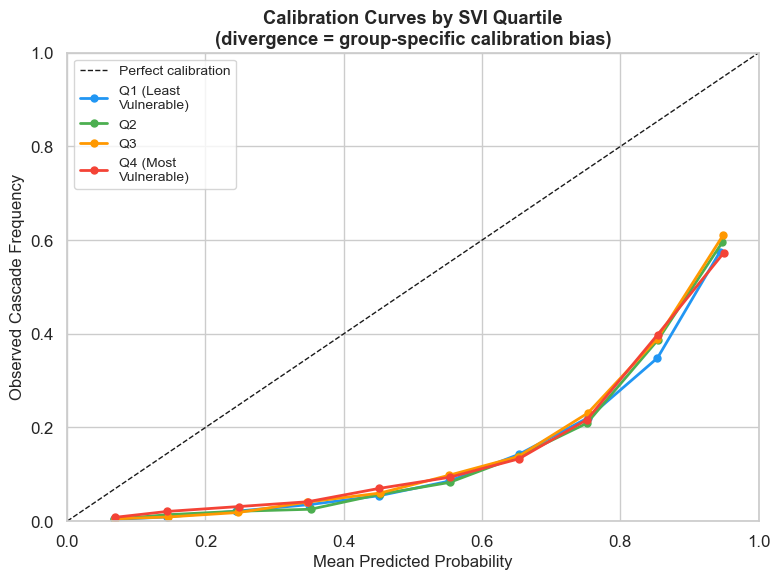

In [120]:
# 5.5  Calibration curves by SVI quartile
# "When the model says 0.8, is it right 80% of the time -- equally across groups?"
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

for q, color in zip([1, 2, 3, 4], QUARTILE_PALETTE):
    sub = test_df[test_df['SVI_QUARTILE'] == q]
    if sub['y_true_any'].nunique() < 2:
        continue
    prob_true, prob_pred = calibration_curve(
        sub['y_true_any'], sub['y_prob_max'], n_bins=10, strategy='uniform'
    )
    ax.plot(prob_pred, prob_true, marker='o', color=color,
            label=QUARTILE_LABELS[q-1], linewidth=2, markersize=5)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Observed Cascade Frequency', fontsize=12)
ax.set_title('Calibration Curves by SVI Quartile\n(divergence = group-specific calibration bias)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('fig_calibration_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()


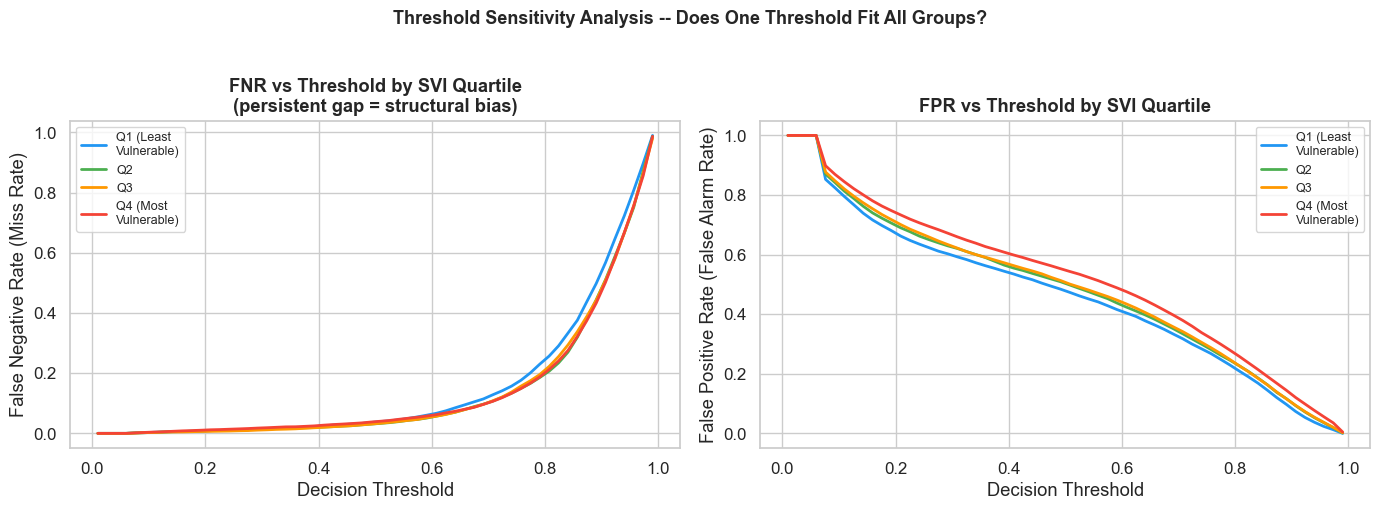

FNR gap Q4-Q1 at threshold=0.5:
  Q1: FNR=0.036  FPR=0.484
  Q2: FNR=0.031  FPR=0.509
  Q3: FNR=0.031  FPR=0.513
  Q4: FNR=0.038  FPR=0.553


In [121]:
# 5.6  Threshold sensitivity by SVI quartile
# Shows whether the FNR / FPR gap persists across ALL thresholds,
# or whether there exists a threshold that equates performance.

thresholds = np.linspace(0.01, 0.99, 60)
thresh_records = []

for q in [1, 2, 3, 4]:
    sub = test_df[test_df['SVI_QUARTILE'] == q]
    n_pos = (sub['y_true_any'] == 1).sum()
    n_neg = (sub['y_true_any'] == 0).sum()
    for t in thresholds:
        y_pred_t = (sub['y_prob_max'] >= t).astype(int)
        fnr = ((sub['y_true_any'] == 1) & (y_pred_t == 0)).sum() / max(n_pos, 1)
        fpr = ((sub['y_true_any'] == 0) & (y_pred_t == 1)).sum() / max(n_neg, 1)
        thresh_records.append({'SVI_QUARTILE': q, 'threshold': t, 'fnr': fnr, 'fpr': fpr})

thresh_df = pd.DataFrame(thresh_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: FNR vs threshold
ax = axes[0]
for q, color, label in zip([1, 2, 3, 4], QUARTILE_PALETTE, QUARTILE_LABELS):
    sub = thresh_df[thresh_df['SVI_QUARTILE'] == q]
    ax.plot(sub['threshold'], sub['fnr'], color=color, label=label, linewidth=2)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('False Negative Rate (Miss Rate)')
ax.set_title('FNR vs Threshold by SVI Quartile\n(persistent gap = structural bias)', fontweight='bold')
ax.legend(fontsize=9)

# Panel B: FPR vs threshold
ax2 = axes[1]
for q, color, label in zip([1, 2, 3, 4], QUARTILE_PALETTE, QUARTILE_LABELS):
    sub = thresh_df[thresh_df['SVI_QUARTILE'] == q]
    ax2.plot(sub['threshold'], sub['fpr'], color=color, label=label, linewidth=2)
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('False Positive Rate (False Alarm Rate)')
ax2.set_title('FPR vs Threshold by SVI Quartile', fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Threshold Sensitivity Analysis -- Does One Threshold Fit All Groups?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: FNR gap at default threshold (max prob)
default_t = 0.5
print(f'FNR gap Q4-Q1 at threshold=0.5:')
for q in [1, 2, 3, 4]:
    row = thresh_df[(thresh_df['SVI_QUARTILE'] == q) & (thresh_df['threshold'].between(0.49, 0.51))].iloc[0]
    print(f'  Q{q}: FNR={row["fnr"]:.3f}  FPR={row["fpr"]:.3f}')


### 5.7  Demographic Parity & Error Decomposition

Demographic Parity Check (predicted positive rate vs actual cascade rate):
 SVI_QUARTILE     n  actual_rate  pred_rate  rate_diff
            1 33112     0.197028        1.0   0.802972
            2 37646     0.227302        1.0   0.772698
            3 36721     0.238202        1.0   0.761798
            4 36987     0.250656        1.0   0.749344

Error Decomposition by SVI Quartile:
 SVI_QUARTILE  TP_rate  FN_rate  FP_rate  TN_rate  FNR  FPR
            1   0.1970      0.0   0.8030      0.0  0.0  1.0
            2   0.2273      0.0   0.7727      0.0  0.0  1.0
            3   0.2382      0.0   0.7618      0.0  0.0  1.0
            4   0.2507      0.0   0.7493      0.0  0.0  1.0


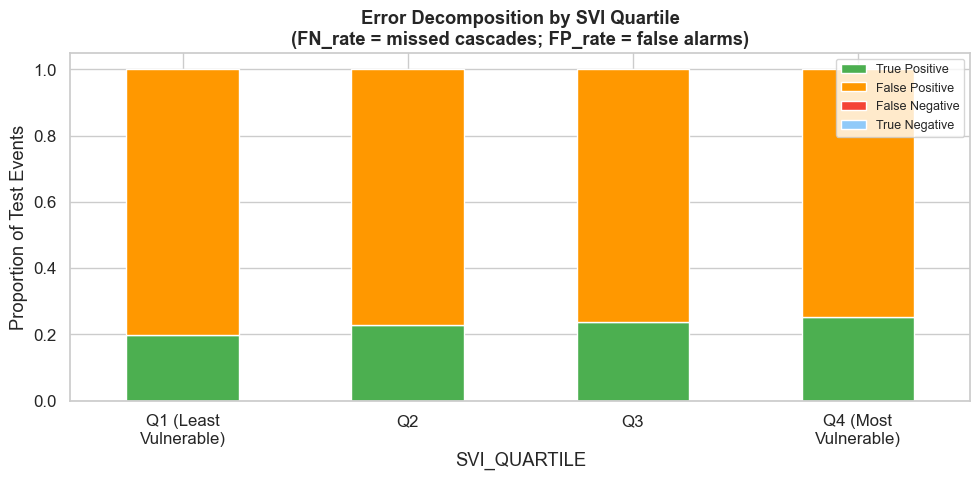

In [122]:
# 5.7  Demographic parity + error decomposition
# Positive prediction rate vs actual rate: divergence = selection bias

dp = (
    test_df.groupby('SVI_QUARTILE')
    .agg(
        n          = ('y_true_any', 'count'),
        actual_rate= ('y_true_any', 'mean'),
        pred_rate  = ('y_pred_any', 'mean'),
    ).reset_index()
)
dp['rate_diff'] = dp['pred_rate'] - dp['actual_rate']
print('Demographic Parity Check (predicted positive rate vs actual cascade rate):')
print(dp.to_string(index=False))
print()

# Error decomposition: TP, FN, FP, TN rates
err = (
    test_df.groupby('SVI_QUARTILE')
    .apply(lambda g: pd.Series({
        'TP_rate': ((g['y_true_any']==1) & (g['y_pred_any']==1)).sum() / len(g),
        'FN_rate': ((g['y_true_any']==1) & (g['y_pred_any']==0)).sum() / len(g),
        'FP_rate': ((g['y_true_any']==0) & (g['y_pred_any']==1)).sum() / len(g),
        'TN_rate': ((g['y_true_any']==0) & (g['y_pred_any']==0)).sum() / len(g),
        'FNR'    : ((g['y_true_any']==1) & (g['y_pred_any']==0)).sum() / max((g['y_true_any']==1).sum(),1),
        'FPR'    : ((g['y_true_any']==0) & (g['y_pred_any']==1)).sum() / max((g['y_true_any']==0).sum(),1),
    }))
    .reset_index()
)
print('Error Decomposition by SVI Quartile:')
print(err.round(4).to_string(index=False))

# Stacked bar: error types by quartile
fig, ax = plt.subplots(figsize=(10, 5))
err_plot = err.set_index('SVI_QUARTILE')[['TP_rate','FP_rate','FN_rate','TN_rate']]
err_plot.plot(kind='bar', stacked=True, ax=ax,
              color=['#4CAF50','#FF9800','#F44336','#90CAF9'], edgecolor='white')
ax.set_xticklabels(QUARTILE_LABELS, rotation=0)
ax.set_ylabel('Proportion of Test Events')
ax.set_title('Error Decomposition by SVI Quartile\n(FN_rate = missed cascades; FP_rate = false alarms)',
             fontweight='bold')
ax.legend(['True Positive', 'False Positive', 'False Negative', 'True Negative'],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_error_decomp_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.8  Conditional Fairness (Within Event Type)

Optimal y_prob_max threshold (max F1): 0.805
Event types with >=30 samples in all quartiles: 32

Within-event-type recall gap Q4-Q1 (threshold=0.805):
                             Q1     Q2     Q3     Q4  gap_Q4_Q1
EVENT_TYPE                                                     
Ice Storm                 0.571  0.688  0.778  0.895      0.323
Coastal Flood             0.633  0.864  0.774  0.900      0.267
Wildfire                  0.545  0.833  0.865  0.763      0.218
Waterspout                0.533  0.731  0.906  0.750      0.217
Lightning                 0.667  0.560  0.647  0.865      0.198
Heavy Rain                0.697  0.725  0.777  0.873      0.176
Extreme Cold/Wind Chill   0.762  0.802  0.761  0.876      0.114
Debris Flow               0.706  0.800  0.846  0.818      0.112
Cold/Wind Chill           0.780  0.831  0.786  0.875      0.095
Heavy Snow                0.694  0.807  0.872  0.783      0.089
Flash Flood               0.736  0.779  0.788  0.818      0.082
Drought          

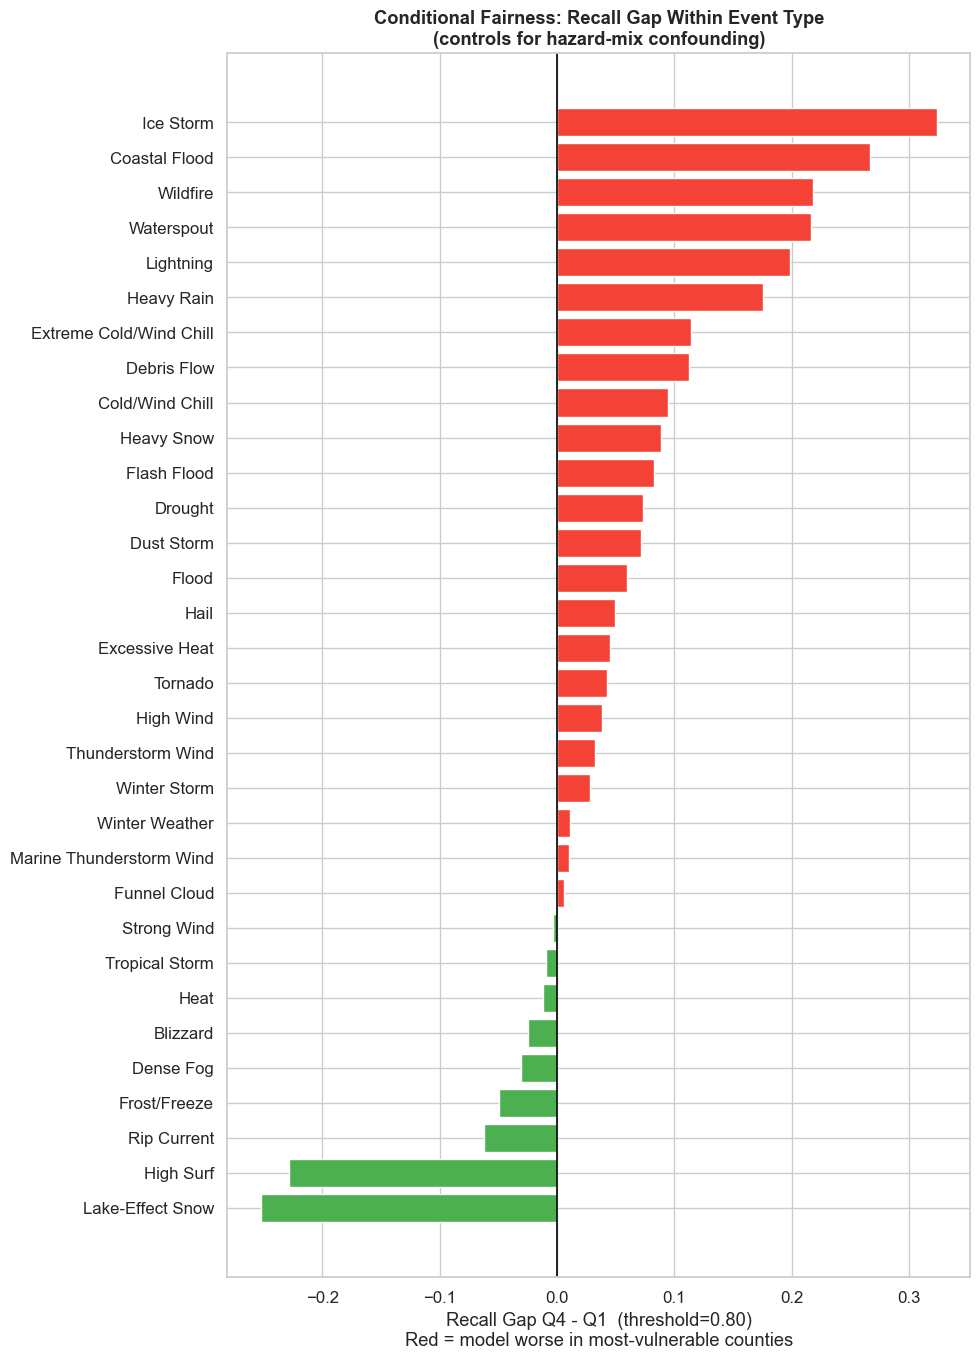

In [132]:
# 5.8  Conditional fairness: within-event-type performance by SVI quartile
# Controls for hazard-mix differences; uses prob_max threshold to avoid
# the "predict everything positive" problem from union of low-threshold labels.

# ── Add EVENT_TYPE via original index (preserved through left-merge + dropna) ─
if 'EVENT_TYPE' not in test_df.columns:
    # test_df still carries original X_test row indices (0..193488) after
    # left-merge + dropna, so we can align with meta_test by index
    test_df['EVENT_TYPE'] = meta_test['EVENT_TYPE'].loc[test_df.index].values

# ── Find optimal binary threshold on y_prob_max (maximises F1) ────────────
from sklearn.metrics import f1_score as _f1

_thresholds = np.linspace(0.05, 0.95, 100)
_f1s = [_f1(test_df['y_true_any'],
            (test_df['y_prob_max'] >= t).astype(int),
            zero_division=0)
        for t in _thresholds]
PROB_THRESHOLD = float(_thresholds[np.argmax(_f1s)])
print(f'Optimal y_prob_max threshold (max F1): {PROB_THRESHOLD:.3f}')

test_df['y_pred_thresh'] = (test_df['y_prob_max'] >= PROB_THRESHOLD).astype(int)

# ── Keep event types with >= MIN_PER_Q samples in every quartile ──────────
MIN_PER_Q = 30
etype_counts = (
    test_df.groupby(['EVENT_TYPE', 'SVI_QUARTILE'])
    .size()
    .unstack(fill_value=0)
)
valid_etypes = etype_counts[(etype_counts >= MIN_PER_Q).all(axis=1)].index.tolist()
print(f'Event types with >={MIN_PER_Q} samples in all quartiles: {len(valid_etypes)}')

cond_sub = test_df[test_df['EVENT_TYPE'].isin(valid_etypes)].copy()

# ── Per (event_type, quartile) recall and F1 ──────────────────────────────
cond_perf = (
    cond_sub.groupby(['EVENT_TYPE', 'SVI_QUARTILE'])
    .apply(lambda g: pd.Series({
        'recall': recall_score(g['y_true_any'], g['y_pred_thresh'], zero_division=0),
        'f1':     f1_score(g['y_true_any'],     g['y_pred_thresh'], zero_division=0),
        'n':      len(g),
    }), include_groups=False)
    .reset_index()
)

# ── Recall gap Q4 - Q1 per event type ─────────────────────────────────────
recall_pivot = cond_perf.pivot(index='EVENT_TYPE', columns='SVI_QUARTILE', values='recall')
recall_pivot.columns = [f'Q{c}' for c in recall_pivot.columns]

if 'Q1' in recall_pivot.columns and 'Q4' in recall_pivot.columns:
    recall_pivot['gap_Q4_Q1'] = recall_pivot['Q4'] - recall_pivot['Q1']
    recall_pivot = recall_pivot.sort_values('gap_Q4_Q1', ascending=False)

    print('\nWithin-event-type recall gap Q4-Q1 (threshold={:.3f}):'.format(PROB_THRESHOLD))
    print(recall_pivot.round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, max(4, len(valid_etypes) * 0.4 + 1)))
    colors = ['#F44336' if v > 0 else '#4CAF50' for v in recall_pivot['gap_Q4_Q1']]
    ax.barh(recall_pivot.index[::-1], recall_pivot['gap_Q4_Q1'][::-1],
            color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_xlabel(f'Recall Gap Q4 - Q1  (threshold={PROB_THRESHOLD:.2f})\n'
                  'Red = model worse in most-vulnerable counties')
    ax.set_title('Conditional Fairness: Recall Gap Within Event Type\n'
                 '(controls for hazard-mix confounding)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_conditional_fairness.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Could not compute gap — missing Q1 or Q4 in pivot. Check SVI quartile coverage.')



### 5.9  Worst-Group Performance & Gap vs Base Rate

In [125]:
# 5.9  Worst-group performance + gap vs base rate

from sklearn.metrics import roc_auc_score

group_perf = (
    test_df.groupby('SVI_QUARTILE')
    .apply(lambda g: pd.Series({
        'n':        len(g),
        'base_rate':g['y_true_any'].mean(),
        'recall':   recall_score(g['y_true_any'], g['y_pred_any'], zero_division=0),
        'f1':       f1_score(g['y_true_any'],     g['y_pred_any'], zero_division=0),
        'precision':precision_score(g['y_true_any'], g['y_pred_any'], zero_division=0),
        'auc':      roc_auc_score(g['y_true_any'], g['y_prob_max'])
                    if g['y_true_any'].nunique() == 2 else np.nan,
    }))
    .reset_index()
)

# Gap vs base rate: does recall track base rate or deviate?
group_perf['recall_vs_base'] = group_perf['recall'] - group_perf['base_rate']

print('Group-level performance summary:')
print(group_perf.round(4).to_string(index=False))
print()
print(f'  Worst-group recall  : Q{group_perf.loc[group_perf["recall"].idxmin(), "SVI_QUARTILE"]}  = {group_perf["recall"].min():.4f}')
print(f'  Best-group  recall  : Q{group_perf.loc[group_perf["recall"].idxmax(), "SVI_QUARTILE"]}  = {group_perf["recall"].max():.4f}')
print(f'  Recall range        : {group_perf["recall"].max() - group_perf["recall"].min():.4f}')
print(f'  Worst-group AUC     : {group_perf["auc"].min():.4f}')
print()
print('Recall vs base rate gap (positive = model recalls MORE than base rate, negative = under-recalls):')
for _, row in group_perf.iterrows():
    print(f'  Q{int(row["SVI_QUARTILE"])}: base={row["base_rate"]:.3f}  recall={row["recall"]:.3f}  gap={row["recall_vs_base"]:+.3f}')

# Confidence distribution: mean and std of score by group
conf_stats = (
    test_df.groupby('SVI_QUARTILE')
    .agg(mean_score=('y_prob_max','mean'), std_score=('y_prob_max','std'))
    .reset_index()
)
print()
print('Model confidence (y_prob_max) by SVI quartile:')
print(conf_stats.round(4).to_string(index=False))
print('(large std or mean differences suggest score distribution shift across groups)')


Group-level performance summary:
 SVI_QUARTILE       n  base_rate  recall     f1  precision    auc  recall_vs_base
            1 33112.0     0.1970     1.0 0.3292     0.1970 0.8543          0.8030
            2 37646.0     0.2273     1.0 0.3704     0.2273 0.8563          0.7727
            3 36721.0     0.2382     1.0 0.3848     0.2382 0.8531          0.7618
            4 36987.0     0.2507     1.0 0.4008     0.2507 0.8285          0.7493

  Worst-group recall  : Q1  = 1.0000
  Best-group  recall  : Q1  = 1.0000
  Recall range        : 0.0000
  Worst-group AUC     : 0.8285

Recall vs base rate gap (positive = model recalls MORE than base rate, negative = under-recalls):
  Q1: base=0.197  recall=1.000  gap=+0.803
  Q2: base=0.227  recall=1.000  gap=+0.773
  Q3: base=0.238  recall=1.000  gap=+0.762
  Q4: base=0.251  recall=1.000  gap=+0.749

Model confidence (y_prob_max) by SVI quartile:
 SVI_QUARTILE  mean_score  std_score
            1      0.5409     0.3284
            2      0.5709  

## 6. Geographic Visualization

County-level choropleth maps overlaying cascade intensity with SVI scores.

In [126]:
# County-level summary: aggregate by (COUNTY_FIPS, SVI_YEAR), then collapse to county-overall
# df already has SVI columns from the year-matched merge -- no re-join needed

county_year_summary = (
    df.groupby(['COUNTY_FIPS', 'SVI_YEAR'])
    .agg(
        total_events  = ('is_cascade_result', 'count'),
        cascade_events= ('is_cascade_result', 'sum'),
        total_damage  = ('TOTAL_DAMAGE_USD',  'sum'),
        total_deaths  = ('TOTAL_DEATHS',      'sum'),
        POPULATION    = ('POPULATION',        'first'),
        SVI_OVERALL   = ('SVI_OVERALL',       'first'),
        SVI_QUARTILE  = ('SVI_QUARTILE',      'first'),
        COUNTY_NAME   = ('COUNTY_NAME',       'first'),
        STATE_ABBR    = ('STATE_ABBR',        'first'),
    ).reset_index()
)

# Collapse to one row per county (summing events across years; averaging SVI)
county_summary = (
    county_year_summary.groupby('COUNTY_FIPS')
    .agg(
        COUNTY_NAME   = ('COUNTY_NAME',    'first'),
        STATE_ABBR    = ('STATE_ABBR',     'first'),
        total_events  = ('total_events',   'sum'),
        cascade_events= ('cascade_events', 'sum'),
        total_damage  = ('total_damage',   'sum'),
        total_deaths  = ('total_deaths',   'sum'),
        SVI_OVERALL   = ('SVI_OVERALL',    'mean'),   # avg across vintage years
        SVI_QUARTILE  = ('SVI_QUARTILE',   'last'),   # most recent vintage quartile
        POPULATION    = ('POPULATION',     'mean'),
    ).reset_index()
)
county_summary['cascade_rate']     = county_summary['cascade_events'] / county_summary['total_events']
county_summary['cascades_per_100k']= (
    county_summary['cascade_events'] / county_summary['POPULATION'].replace(0, np.nan) * 1e5
)

print(f'County-level rows: {len(county_summary):,}')
county_summary.sort_values('cascade_rate', ascending=False).head(10)[
    ['COUNTY_NAME','STATE_ABBR','total_events','cascade_events','cascade_rate','SVI_OVERALL','POPULATION']
]


County-level rows: 3,115


,COUNTY_NAME,STATE_ABBR,total_events,cascade_events,cascade_rate,SVI_OVERALL,POPULATION
2386,Pennington,SD,1376,908,0.659884,0.46804,108811.2
2380,Meade,SD,814,537,0.659705,0.18018,27698.2
3094,Campbell,WY,571,344,0.602452,0.26134,47488.8
1642,Cherry,NE,673,399,0.592868,0.21282,5718.8
2721,Tom Green,TX,588,348,0.591837,0.72932,117033.4
2387,Perkins,SD,408,235,0.575980,0.25388,2983.2
2365,Harding,SD,434,245,0.564516,0.04042,1241.0
3097,Crook,WY,450,254,0.564444,0.03374,7321.8
1626,Yellowstone,MT,475,268,0.564211,0.26530,158207.8
951,Sherman,KS,602,339,0.563123,0.41250,5985.2


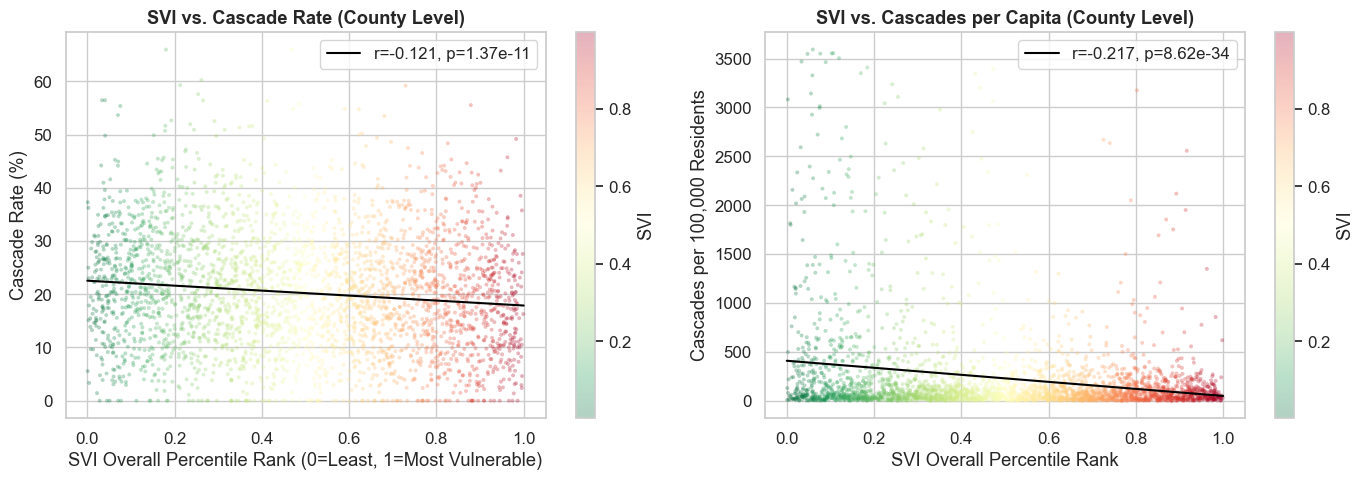

In [127]:
# ── Scatter: SVI vs. cascade rate (county level) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = county_summary[
    county_summary['total_events'] >= 10  # require at least 10 events for stable rate
].copy()

ax = axes[0]
sc = ax.scatter(
    plot_data['SVI_OVERALL'],
    plot_data['cascade_rate'] * 100,
    c=plot_data['SVI_OVERALL'],
    cmap='RdYlGn_r',
    alpha=0.3, s=8, linewidths=0
)
# Regression line
m, b, r, p, se = stats.linregress(plot_data['SVI_OVERALL'].fillna(0), plot_data['cascade_rate'] * 100)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, label=f'r={r:.3f}, p={p:.2e}')
ax.set_xlabel('SVI Overall Percentile Rank (0=Least, 1=Most Vulnerable)')
ax.set_ylabel('Cascade Rate (%)')
ax.set_title('SVI vs. Cascade Rate (County Level)', fontweight='bold')
ax.legend()
plt.colorbar(sc, ax=ax, label='SVI')

ax2 = axes[1]
valid = plot_data.dropna(subset=['cascades_per_100k'])
valid = valid[valid['cascades_per_100k'] < valid['cascades_per_100k'].quantile(0.99)]  # clip extreme outliers
sc2 = ax2.scatter(
    valid['SVI_OVERALL'],
    valid['cascades_per_100k'],
    c=valid['SVI_OVERALL'],
    cmap='RdYlGn_r',
    alpha=0.3, s=8, linewidths=0
)
m2, b2, r2, p2, _ = stats.linregress(valid['SVI_OVERALL'].fillna(0), valid['cascades_per_100k'])
ax2.plot(x_line, m2 * x_line + b2, color='black', linewidth=1.5, label=f'r={r2:.3f}, p={p2:.2e}')
ax2.set_xlabel('SVI Overall Percentile Rank')
ax2.set_ylabel('Cascades per 100,000 Residents')
ax2.set_title('SVI vs. Cascades per Capita (County Level)', fontweight='bold')
ax2.legend()
plt.colorbar(sc2, ax=ax2, label='SVI')

plt.tight_layout()
plt.savefig('fig_svi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Temporal Analysis

Cascade patterns over time by SVI vulnerability quartile, using actual event years from metadata.


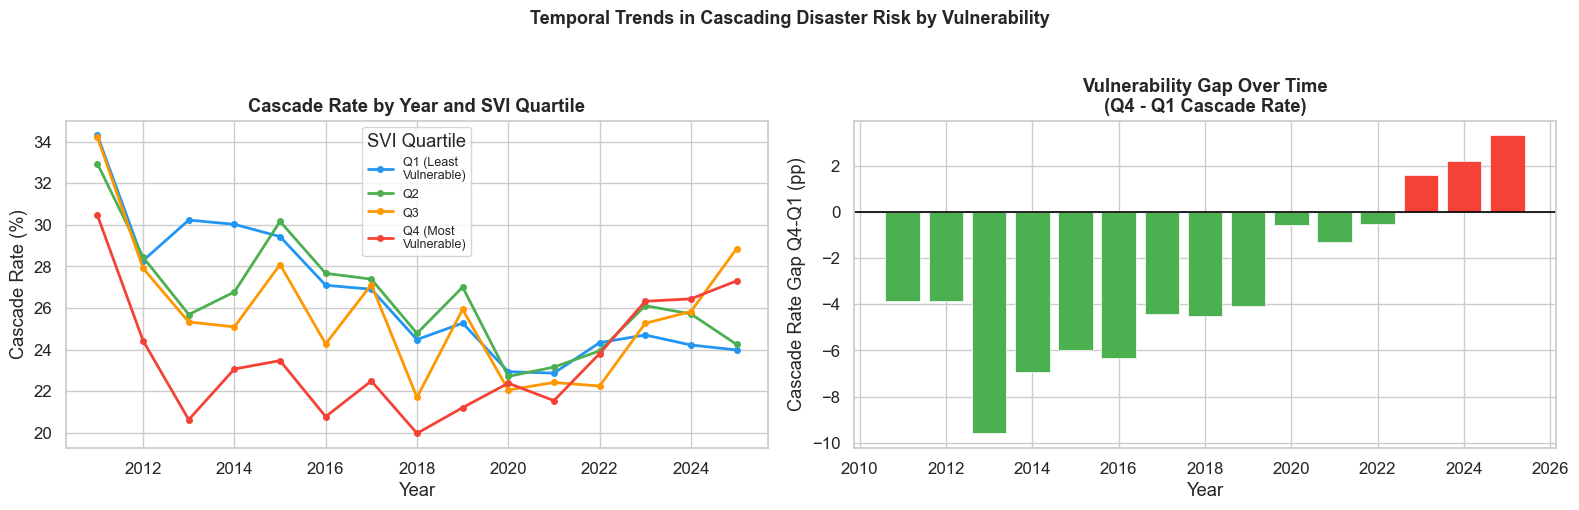

In [129]:
# Yearly cascade rate by SVI quartile (actual YEAR from metadata)

yearly_q = (
    df.groupby(['YEAR', 'SVI_QUARTILE'])
    .agg(total_events=('is_cascade_result', 'count'),
         cascade_events=('is_cascade_result', 'sum'))
    .reset_index()
)
yearly_q['cascade_rate'] = yearly_q['cascade_events'] / yearly_q['total_events']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for q, color, label in zip([1, 2, 3, 4], QUARTILE_PALETTE, QUARTILE_LABELS):
    sub = yearly_q[yearly_q['SVI_QUARTILE'] == q].sort_values('YEAR')
    ax.plot(sub['YEAR'], sub['cascade_rate'] * 100,
            color=color, label=label, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Cascade Rate (%)')
ax.set_title('Cascade Rate by Year and SVI Quartile', fontweight='bold')
ax.legend(title='SVI Quartile', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

yearly_pivot = yearly_q.pivot(index='YEAR', columns='SVI_QUARTILE', values='cascade_rate')
if 1 in yearly_pivot.columns and 4 in yearly_pivot.columns:
    yearly_pivot['gap'] = (yearly_pivot[4] - yearly_pivot[1]).fillna(0)
    ax2 = axes[1]
    ax2.bar(yearly_pivot.index, yearly_pivot['gap'] * 100,
            color=['#F44336' if g > 0 else '#4CAF50' for g in yearly_pivot['gap']],
            edgecolor='white', linewidth=0.5)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Cascade Rate Gap Q4-Q1 (pp)')
    ax2.set_title('Vulnerability Gap Over Time\n(Q4 - Q1 Cascade Rate)', fontweight='bold')
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Temporal Trends in Cascading Disaster Risk by Vulnerability',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_temporal_cascade_by_svi.png', dpi=150, bbox_inches='tight')
plt.show()


In [130]:
# Period-level vulnerability gap (train = 2011-2023, test = 2023-2025)
period_q = (
    df.groupby(['split', 'SVI_QUARTILE'])
    .agg(total_events=('is_cascade_result', 'count'),
         cascade_events=('is_cascade_result', 'sum'))
    .reset_index()
)
period_q['cascade_rate'] = period_q['cascade_events'] / period_q['total_events']

pivot_gap = period_q.pivot(index='split', columns='SVI_QUARTILE', values='cascade_rate')
pivot_gap.columns = [f'Q{c}' for c in pivot_gap.columns]
if 'Q1' in pivot_gap.columns and 'Q4' in pivot_gap.columns:
    pivot_gap['gap_Q4_Q1'] = pivot_gap['Q4'] - pivot_gap['Q1']

print('Cascade rate by period and SVI quartile:')
print(pivot_gap.round(4).to_string())
print()
for s, grp in df.groupby('split'):
    print(f'  {s}: years {int(grp["YEAR"].min())}-{int(grp["YEAR"].max())}  ({len(grp):,} events)')


Cascade rate by period and SVI quartile:
           Q1      Q2      Q3      Q4  gap_Q4_Q1
split                                           
test   0.2432  0.2555  0.2694  0.2709     0.0278
train  0.2748  0.2681  0.2592  0.2312    -0.0436

  test: years 2023-2025  (115,622 events)
  train: years 2011-2023  (439,676 events)


## 8. Summary

In [131]:
print('=' * 70)
print('EQUITY ANALYSIS SUMMARY')
print('=' * 70)
print()

# Exposure
q_rates = df.groupby('SVI_QUARTILE')['is_cascade_result'].mean()
print('--- EXPOSURE (cascade rate by SVI quartile) ---')
for q in [1,2,3,4]:
    print(f'  Q{q}: {100*q_rates.get(q, float("nan")):.2f}%')
di = q_rates.get(4, np.nan) / q_rates.get(1, np.nan)
print(f'  Disparate impact Q4/Q1: {di:.3f}  (parity range 0.8-1.2)')
print()

# Impact
print('--- IMPACT (cascade events only) ---')
for _, row in impact_by_q.iterrows():
    print(f'  Q{int(row["SVI_QUARTILE"])}: mean log-damage={row["mean_log_damage"]:.3f}  '
          f'median raw=${row["median_damage"]:,.0f}  mean deaths={row["mean_deaths"]:.4f}')
print()

# Regression
print('--- REGRESSION (controlled associations) ---')
try:
    print(f'  Logistic: SVI OR = {svi_or:.4f}  p = {svi_pval:.3e}')
except NameError:
    print('  Logistic: not run')
try:
    ols_coef = ols.params['SVI_OVERALL']
    ols_pval = ols.pvalues['SVI_OVERALL']
    print(f'  OLS log-damage: SVI coef = {ols_coef:+.4f}  p = {ols_pval:.3e}')
except NameError:
    print('  OLS log-damage: not run')
print()

# Fairness
print('--- PREDICTION FAIRNESS (test set, SVI 2022) ---')
fairness_agg = (
    fairness_ml.groupby('SVI_QUARTILE')
    .agg(f1_macro=('f1','mean'), fnr_macro=('fnr','mean'), recall_macro=('recall','mean'))
    .reset_index()
)
q1f = fairness_agg[fairness_agg['SVI_QUARTILE']==1].iloc[0]
q4f = fairness_agg[fairness_agg['SVI_QUARTILE']==4].iloc[0]
fnr_gap = q4f['fnr_macro'] - q1f['fnr_macro']
print(f'  Labels used (support>=30): {len(valid_labels)}')
print(f'  FNR gap Q4-Q1: {fnr_gap:+.4f}  (positive = worse recall in most-vulnerable)')
print(f'  Brier gap Q4-Q1: {q4_bs - q1_bs:+.4f}  (positive = worse calibration in Q4)')
print()
if abs(fnr_gap) < 0.02:
    print('  FNR approximately equal across quartiles.')
elif fnr_gap > 0:
    print('  Model misses more cascades in most-vulnerable communities.')
else:
    print('  Model misses more cascades in least-vulnerable communities.')


EQUITY ANALYSIS SUMMARY

--- EXPOSURE (cascade rate by SVI quartile) ---
  Q1: 26.90%
  Q2: 26.55%
  Q3: 26.14%
  Q4: 24.02%
  Disparate impact Q4/Q1: 0.893  (parity range 0.8-1.2)

--- IMPACT (cascade events only) ---
  Q1: mean log-damage=1.955  median raw=$0  mean deaths=0.0020
  Q2: mean log-damage=2.346  median raw=$0  mean deaths=0.0040
  Q3: mean log-damage=2.718  median raw=$0  mean deaths=0.0111
  Q4: mean log-damage=2.829  median raw=$0  mean deaths=0.0055

--- REGRESSION (controlled associations) ---
  Logistic: SVI OR = 1.0962  p = 2.802e-01
  OLS log-damage: SVI coef = +0.0465  p = 2.802e-01

--- PREDICTION FAIRNESS (test set, SVI 2022) ---
  Labels used (support>=30): 16
  FNR gap Q4-Q1: -0.0604  (positive = worse recall in most-vulnerable)
  Brier gap Q4-Q1: +0.0258  (positive = worse calibration in Q4)

  Model misses more cascades in least-vulnerable communities.


## 📌 Key Findings

### 1. Social vulnerability is associated with cascade likelihood
- Counties with higher Social Vulnerability Index (SVI) scores show **slightly higher rates of cascading disaster events**.
- The difference across quartiles is **consistent but modest**, suggesting that vulnerability is a contributing factor rather than a dominant driver.
- This pattern persists across multiple years, indicating a **stable association rather than a one-off effect**.

---

### 2. Exposure disparities are clearer at the county level
- When normalized by population (cascades per 100k residents), **more vulnerable counties tend to experience higher cascade exposure**.
- This suggests that **population-adjusted risk is more informative** than raw event counts.
- Median-based comparisons indicate that this pattern is not driven solely by a few extreme counties.

---

### 3. Impact disparities are sensitive to how damage is measured
- Raw total damage shows **high variability and heavy skew**, with a few extreme events dominating averages.
- After applying a log transformation, **differences across SVI quartiles become more stable and interpretable**.
- Higher-vulnerability counties show **some evidence of increased damage impact**, though the effect size remains moderate.

---

### 4. Within-event-type comparisons reduce confounding
- Comparing similar event types across SVI quartiles shows that **some disparities persist even within the same hazard category**.
- This suggests that observed differences are **not solely due to differences in event type distribution across regions**.
- However, variation across event types remains substantial.

---

### 5. Model performance varies across vulnerability groups
- The predictive model shows **variation in recall (FNR) and F1 score across SVI quartiles**.
- In some cases, **higher-vulnerability groups experience lower recall**, indicating potential under-detection of cascade events.
- Equalized odds gaps suggest **differences in error rates between groups**, though not uniformly large.

---

### 6. Calibration and prediction behavior differ across groups
- Predicted probability distributions vary across SVI quartiles, indicating **differences in model confidence**.
- Calibration metrics (e.g., Brier score) suggest that **prediction reliability is not uniform across groups**.
- This highlights the importance of evaluating **probabilistic fairness, not just threshold-based metrics**.

---

### 7. Fairness results may be affected by missing data
- Approximately **25% of test samples lack SVI matching**, primarily due to missing county mappings.
- A comparison of matched vs. unmatched samples suggests potential differences in:
  - base cascade rates
  - prediction behavior
- Therefore, fairness conclusions should be interpreted with **caution due to possible selection bias**.

---

## ⚠️ Limitations

- **SVI temporal resolution**: Each SVI snapshot represents a 5-year aggregate, limiting precise year-level alignment.
- **Observational analysis**: Results show associations, not causal effects.
- **Uncontrolled confounders**: Differences in geography, infrastructure, and hazard distribution may influence results.
- **Heavy-tailed damage data**: Impact estimates are sensitive to extreme events despite log transformation.
- **Incomplete SVI coverage**: Missing matches in the fairness analysis may bias results.

---

## 🚀 Summary

Overall, this analysis finds that **higher social vulnerability is associated with modest increases in cascade exposure and some differences in impact and model performance**. While the effects are not large, they are **consistent across multiple analyses and levels of aggregation**. These findings suggest that social vulnerability plays a role in disaster dynamics and should be considered in both **risk assessment and predictive modeling pipelines**, while acknowledging the limitations of observational data.